In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
import os
sys.path.append(os.path.abspath("/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main"))

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sparsecca import cca_pmd
from gprofiler import GProfiler

## zscore

In [7]:
data = pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/paired_mutant_shrvar_zscore.csv')

#### Split the genes

In [9]:
def split_genes_with_counts(data):
    rows = []
    for _, row in data.iterrows():
        full_genes = str(row['mutated_genes']).strip()
        genes = [g.strip() for g in full_genes.replace('&', ',').split(',') if g.strip()]
        mutation_count = len(genes)
        for gene in genes:
            new_row = row.copy()
            new_row['mutated_genes'] = gene
            new_row['full_mutated_genes'] = full_genes
            new_row['mutation_count'] = mutation_count
            # Append mutation count to mutant_ID
            new_row['mutant_ID'] = f"{row['mutant_ID']}({mutation_count})"
            rows.append(new_row)
    data_expanded = pd.DataFrame(rows).reset_index(drop=True)
    if data_expanded.empty:
        print("Warning: no rows generated in split_genes_with_counts")
    return data_expanded

#data = pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/Bayesian_latest_phase2(5.18).csv')
#data_orig = pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Quantile_normalization/2025_5_phase2_light_status_slope_QtilNorm_randeffONLYPLATES_ontimepoints.csv')
data = split_genes_with_counts(data)
#data.to_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/2025_5_phase2_light_status_slope_split_genes.csv', index=False)

## Sparse CCA

use the z-scores maybe instead of theplots

Cleaned X: (1070, 586) Y PCs: (1070, 7)

=== Canonical Component 1 ===
Correlation: 0.491
Correlated genes: ['Cre12.g531900', 'Cre04.g213652', 'Cre12.g495250', 'Cre08.g358571', 'Cre16.g685451', 'Cre06.g251050', 'Cre13.g565150', 'Cre11.g467756', 'Cre04.g229163', 'Cre02.g095115', 'Cre04.g214501', 'Cre10.g445800', 'Cre10.g432600', 'Cre10.g436000', 'Cre03.g153400'] ...
Correlated Y PCs: ['PC1']

=== Canonical Component 2 ===
Correlation: 0.587
Correlated genes: ['Cre04.g229163', 'Cre07.g327800', 'Cre13.g565150', 'Cre02.g108500', 'Cre06.g274400', 'Cre02.g095115', 'Cre04.g215800', 'Cre09.g393000', 'Cre01.g000100', 'Cre03.g153400', 'Cre11.g467741', 'Cre02.g112200', 'Cre07.g334950', 'Cre13.g586350', 'Cre16.g676869'] ...
Correlated Y PCs: ['PC2']

=== Canonical Component 3 ===
Correlation: 0.641
Correlated genes: ['Cre07.g327800', 'Cre13.g565150', 'Cre04.g229163', 'Cre01.g000100', 'Cre02.g108500', 'Cre02.g095115', 'Cre02.g146300', 'Cre04.g215800', 'Cre09.g393000', 'Cre07.g334950', 'Cre06.g27440

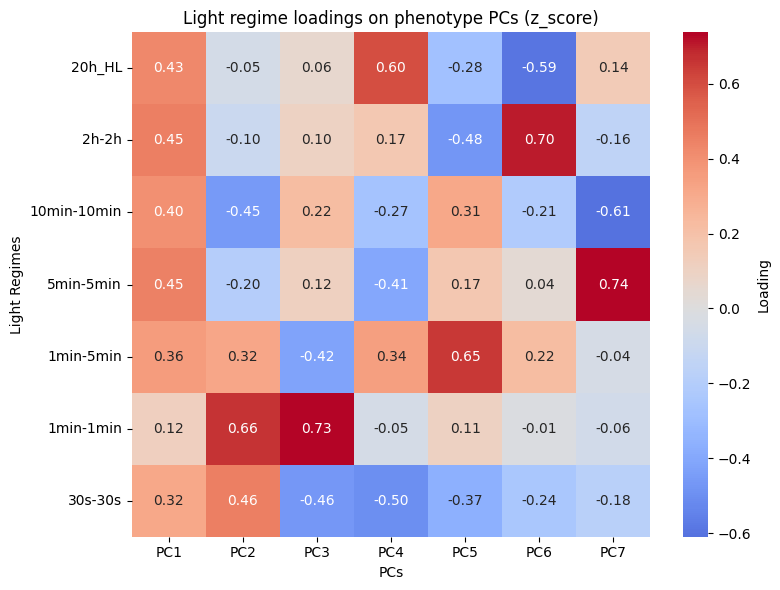

    PC  eigenvalue  variance_ratio  variance_pct  cum_pct
0  PC1       3.258           0.465        46.498   46.498
1  PC2       1.072           0.153        15.306   61.804
2  PC3       0.902           0.129        12.874   74.678
3  PC4       0.640           0.091         9.138   83.816
4  PC5       0.498           0.071         7.102   90.918
5  PC6       0.347           0.050         4.954   95.871
6  PC7       0.289           0.041         4.129  100.000


In [10]:
# K = 2
# penalty_x = 0.3
# penalty_y = 0.3

# df = data#pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/Bayesian_splitgenes_latest_phase2(5.18).csv')
# df = df[~(df['mutant_ID']== 'WT')]  #
# df = df[df['mutated_genes'].notna() & df['mutant_ID'].notna()]
# df = df[~(df['light_regime'].isin(['20h_ML']))]

# # Gene presence/absence matrix : X
# df['presence'] = 1
# X = df.pivot_table(index='mutant_ID', columns='mutated_genes',
#                    values='presence', fill_value=0)
# # Phenotype matrix : Y
# Y = df.pivot_table(index='mutant_ID', columns='light_regime',
#                    values='y2_slope', aggfunc='mean')
# common = X.index.intersection(Y.index)
# X, Y = X.loc[common], Y.loc[common]
# Y = Y.fillna(Y.mean())
# Y = Y.clip(lower=-1e6, upper=1e6)
# X = X.loc[:, X.var() > 0]

# X_scaled = StandardScaler().fit_transform(X)
# Y_scaled = StandardScaler().fit_transform(Y)
# mask = np.isfinite(X_scaled).all(axis=1) & np.isfinite(Y_scaled).all(axis=1)
# X_scaled = X_scaled[mask]
# Y_scaled = Y_scaled[mask]

# print("Cleaned X:", X_scaled.shape, "Cleaned Y:", Y_scaled.shape)
# U, V, D = cca_pmd(
#     X_scaled, Y_scaled,
#     penaltyx=penalty_x,
#     penaltyz=penalty_y,
#     K=K,
#     standardize=False
# )
# results = []
# for k in range(K):
#     X_ck = X_scaled @ U[:, k]
#     Y_ck = Y_scaled @ V[:, k]
#     corr_k = np.corrcoef(X_ck, Y_ck)[0, 1]
#     important_genes = X.columns[(abs(U[:, k]) > 1e-4)]
#     important_phenos = Y.columns[(abs(V[:, k]) > 1e-4)]
#     results.append({
#         "component": k+1,
#         "correlation": corr_k,
#         "genes": list(important_genes),
#         "phenotypes": list(important_phenos)
#     })
# for res in results:
#     print(f"\n=== Canonical Component {res['component']} ===")
#     print(f"Correlation: {res['correlation']:.3f}")
#     print("Correlated genes:", res['genes'][:15], "..." if len(res['genes']) > 15 else "")
#     print("Correlated light regimes:", res['phenotypes'])

# genes_used = X.columns
# phenos_used = Y.columns
# records = []
# for k in range(K):
#     X_ck = X_scaled @ U[:, k]
#     Y_ck = Y_scaled @ V[:, k]
#     corr_k = np.corrcoef(X_ck, Y_ck)[0, 1]
#     for gene_idx, gene in enumerate(genes_used):
#         if abs(U[gene_idx, k]) > 1e-4:
#             for pheno_idx, pheno in enumerate(phenos_used):
#                 if abs(V[pheno_idx, k]) > 1e-4:
#                     records.append({
#                         "component": k+1,
#                         "correlation": corr_k,
#                         "gene": gene,
#                         "gene_weight": abs(U[gene_idx, k]),
#                         "light_regime": pheno,
#                         "pheno_weight": abs(V[pheno_idx, k])
#                     })

# results_df = pd.DataFrame(records)
# results_df.to_csv(
#     "/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/cca_correlated_genes_lightregimes_with_weights.csv",
#     index=False
# )
#===================================# PCA of Y before CCA
K = 7
penalty_x = 0.3
penalty_y = 0.3
N_Y_PCS = None 

df = data
df = df[~(df['mutant_ID']== 'WT')]
df = df[df['mutated_genes'].notna() & df['mutant_ID'].notna()]
df = df[~(df['light_regime'].isin(['20h_ML']))]

df['presence'] = 1
X = df.pivot_table(index='mutant_ID', columns='mutated_genes',
                   values='presence', fill_value=0)

Y = df.pivot_table(index='mutant_ID', columns='light_regime',
                   values='z_score', aggfunc='mean')

common = X.index.intersection(Y.index)
X, Y = X.loc[common], Y.loc[common]
Y = Y.fillna(Y.mean())
Y = Y.clip(lower=-1e6, upper=1e6)
X = X.loc[:, X.var() > 0]

X_scaled = StandardScaler().fit_transform(X)
Y_scaled = StandardScaler().fit_transform(Y)

mask = np.isfinite(X_scaled).all(axis=1) & np.isfinite(Y_scaled).all(axis=1)
X_scaled = X_scaled[mask]
Y_scaled = Y_scaled[mask]

pca = PCA(n_components=N_Y_PCS, whiten=False)  
Y_pca_scores = pca.fit_transform(Y_scaled)     # shape: (n_samples, n_pcs)
pc_names = [f"PC{i+1}" for i in range(Y_pca_scores.shape[1])]

print("Cleaned X:", X_scaled.shape, "Y PCs:", Y_pca_scores.shape)

U, V, D = cca_pmd(
    X_scaled, Y_pca_scores,
    penaltyx=penalty_x,
    penaltyz=penalty_y,
    K=K,
    standardize=False
)
results = []
for k in range(K):
    X_ck = X_scaled @ U[:, k]
    Y_ck = Y_pca_scores @ V[:, k]
    corr_k = np.corrcoef(X_ck, Y_ck)[0, 1]
    # Sort important genes by absolute weight
    gene_weights = pd.Series(U[:, k], index=X.columns)
    important_genes = gene_weights[gene_weights.abs() > 1e-4] \
                        .abs() \
                        .sort_values(ascending=False) \
                        .index
    important_pcs = np.array(pc_names)[(abs(V[:, k]) > 1e-4)]
    results.append({
        "component": k+1,
        "correlation": corr_k,
        "genes": list(important_genes),
        "phenotypes": list(important_pcs)  # now PCs, not regimes
    })

for res in results:
    print(f"\n=== Canonical Component {res['component']} ===")
    print(f"Correlation: {res['correlation']:.3f}")
    print("Correlated genes:", res['genes'][:15], "..." if len(res['genes']) > 15 else "")
    print("Correlated Y PCs:", res['phenotypes'])

genes_used = X.columns
phenos_used = pc_names  # PCs used on the Y side

records = []
for k in range(K):
    X_ck = X_scaled @ U[:, k]
    Y_ck = Y_pca_scores @ V[:, k]
    corr_k = np.corrcoef(X_ck, Y_ck)[0, 1]
    for gene_idx, gene in enumerate(genes_used):
        if abs(U[gene_idx, k]) > 1e-4:
            for pheno_idx, pheno in enumerate(phenos_used):
                if abs(V[pheno_idx, k]) > 1e-4:
                    records.append({
                        "component": k+1,
                        "correlation": corr_k,
                        "gene": gene,
                        "gene_weight": abs(U[gene_idx, k]),
                        "light_regime": pheno,  # note: now a PC label
                        "pheno_weight": abs(V[pheno_idx, k])
                    })

results_df = pd.DataFrame(records)
results_df.to_csv(
    "/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/cca_correlated_genes_lightregimes_with_weights.csv",
    index=False
)

#====================PLOTS
# --- imposer l'ordre des régimes sur l'axe Y ---
regime_order = ['20h_HL','20h_ML','2h-2h','10min-10min','5min-5min','1min-5min','1min-1min','30s-30s']
regime_order = [r for r in regime_order if r in Y.columns]  # garde seulement ceux présents

df_loadings = pd.DataFrame(
    pca.components_.T,
    index=Y.columns,
    columns=pc_names
).reindex(regime_order)  # réordonne les lignes

plt.figure(figsize=(8, 6))
sns.heatmap(
    df_loadings, annot=True, fmt=".2f", cmap="coolwarm", center=0,
    cbar_kws={"label": "Loading"}
)
plt.title("Light regime loadings on phenotype PCs (z_score)")
plt.ylabel("Light Regimes")
plt.xlabel("PCs")
plt.tight_layout()
plt.show()

# After fitting PCA -> `pca`
evr = pca.explained_variance_ratio_      # fraction per PC
eig = pca.explained_variance_            # eigenvalues

summary = pd.DataFrame({
    "PC": pc_names,
    "eigenvalue": eig,
    "variance_ratio": evr,
    "variance_pct": 100*evr,
    "cum_pct": 100*np.cumsum(evr)
})
print(summary.round(3))


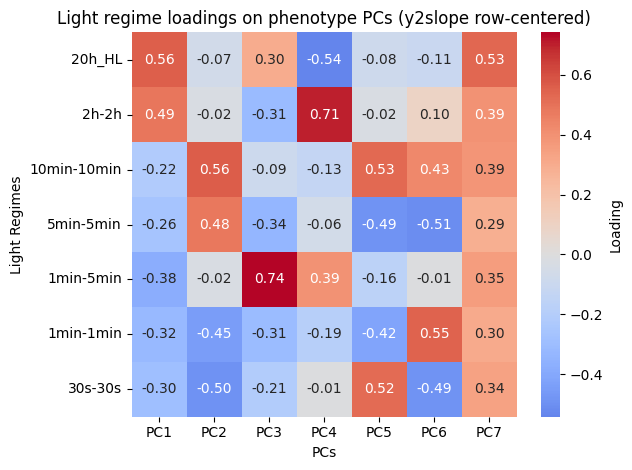

    PC  variance_pct  cum_pct
0  PC1         30.79    30.79
1  PC2         27.13    57.92
2  PC3         14.37    72.29
3  PC4         10.90    83.19
4  PC5          8.79    91.97
5  PC6          8.03   100.00
6  PC7          0.00   100.00


In [12]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# 1) remove per-mutant mean across regimes (row-centering)
Y_rc = Y.sub(Y.mean(axis=1), axis=0)

# 2) z-score columns
Z = pd.DataFrame(
    StandardScaler(with_mean=True, with_std=True).fit_transform(Y_rc),
    index=Y_rc.index, columns=Y_rc.columns
)

# 3) PCA
pca = PCA().fit(Z)
pc_names = [f"PC{i+1}" for i in range(pca.n_components_)]

# 4) loadings heatmap in your desired order
regime_order = ['20h_HL','20h_ML','2h-2h','10min-10min','5min-5min','1min-5min','1min-1min','30s-30s']
regime_order = [r for r in regime_order if r in Z.columns]
df_loadings = pd.DataFrame(pca.components_.T, index=Z.columns, columns=pc_names).reindex(regime_order)

sns.heatmap(df_loadings, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            cbar_kws={"label": "Loading"})
plt.title("Light regime loadings on phenotype PCs (y2slope row-centered)")
plt.ylabel("Light Regimes"); plt.xlabel("PCs"); plt.tight_layout(); plt.show()

# variance explained
evr = pca.explained_variance_ratio_
print(pd.DataFrame({"PC": pc_names, "variance_pct": 100*evr, "cum_pct": 100*np.cumsum(evr)}).round(2))


In [4]:
## transform so it matches the R files
df = pd.read_csv("/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/cca_correlated_genes_lightregimes_with_weights.csv")
all_light_regimes = ["1min-1min", "30s-30s", "20h_HL", "20h_ML",
                     "2h-2h", "10min-10min", "5min-5min", "1min-5min"]
formatted_rows = []
for comp, subdf in df.groupby("component"):
    regime_weights = dict(zip(subdf["light_regime"], subdf["pheno_weight"]))
    for regime in all_light_regimes:
        weight = regime_weights.get(regime, 0)
        formatted_rows.append({
            "component": comp,
            "type": "light_regime",
            "name": regime,
            "weight": weight
        })
    gene_sub = subdf.dropna(subset=["gene"])
    for _, row in gene_sub.iterrows():
        formatted_rows.append({
            "component": comp,
            "type": "gene",
            "name": row["gene"],
            "weight": row["gene_weight"]
        })

formatted_df = pd.DataFrame(formatted_rows)
formatted_df.to_csv("formatted_component_weights.csv", index=False)
formatted_df = formatted_df.drop_duplicates()
formatted_df.to_csv("/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/sCCA/python_scca_pmd_results.csv", index=False)
print(formatted_df.head())

   component          type       name  weight
0          1  light_regime  1min-1min     0.0
1          1  light_regime    30s-30s     0.0
2          1  light_regime     20h_HL     0.0
3          1  light_regime     20h_ML     0.0
4          1  light_regime      2h-2h     0.0


In [ ]:
## Permute to Shuffle the mapping between X and Y (break the true association).
def permutation_fdr(X, Y, penaltyx, penaltyz, K, n_perm=100):
    observed_selected = (np.abs(U) > 1e-4).sum()
    null_selected = []
    X_np = np.asarray(X)
    Y_np = np.asarray(Y)
    for _ in range(n_perm):
        perm_idx = np.random.permutation(Y_np.shape[0])
        Y_perm = Y_np[perm_idx, :]  
        U_perm, V_perm, _ = cca_pmd(
            X_np, Y_perm,
            penaltyx=penaltyx,
            penaltyz=penaltyz,
            K=K,
            standardize=False
        )
        null_selected.append((np.abs(U_perm) > 1e-4).sum())
    expected_fp = np.mean(null_selected)
    fdr = expected_fp / max(observed_selected, 1)
    return fdr
fdr_est = permutation_fdr(X_scaled, Y_scaled, penalty_x, penalty_y, K, n_perm=1000)
print("Estimated FDR:", fdr_est)

## most signif genes

In [ ]:
list_fl = results_df[((results_df['light_regime']=='30s-30s') & (results_df['gene_weight']>0.2))]['gene']
print(list(list_fl))

[]


In [16]:
genes_to_flag = [
    'Cre12.g531900', 'Cre16.g661200', 'Cre07.g314800',
    'Cre13.g588150', 'Cre06.g278110', 'Cre05.g235800',
    'Cre02.g105350', 'Cre13.g581900', 'Cre07.g323450',
    'Cre15.g635800'
]
flagged_hits = results_df[results_df['gene'].isin(genes_to_flag)].copy()
found_genes = set(flagged_hits['gene'])
missing_genes = set(genes_to_flag) - found_genes
print("=== Flagged Genes Found in CCA ===")
print(flagged_hits[['component','light_regime','gene','gene_weight','pheno_weight']].sort_values(['gene','component']))
print("\n=== Flagged Genes Missing from CCA ===")
print(missing_genes if missing_genes else "None — all flagged genes found!")
flagged_hits.to_csv(
    "/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/flagged_genes_in_cca_with_weights.csv",
    index=False
)

=== Flagged Genes Found in CCA ===
     component light_regime           gene  gene_weight  pheno_weight
142          2        2h-2h  Cre02.g105350     0.000201           1.0
373          4    1min-5min  Cre05.g235800     0.004599           1.0
169          2        2h-2h  Cre07.g323450     0.042810           1.0
393          4    1min-5min  Cre07.g323450     0.032225           1.0
85           1    1min-1min  Cre12.g531900     0.395885           1.0
206          2        2h-2h  Cre12.g531900     0.107488           1.0
439          4    1min-5min  Cre12.g531900     0.617097           1.0
449          4    1min-5min  Cre13.g581900     0.151351           1.0
451          4    1min-5min  Cre13.g588150     0.208654           1.0
221          2        2h-2h  Cre15.g635800     0.020781           1.0
457          4    1min-5min  Cre15.g635800     0.059126           1.0

=== Flagged Genes Missing from CCA ===
{'Cre07.g314800', 'Cre16.g661200', 'Cre06.g278110'}


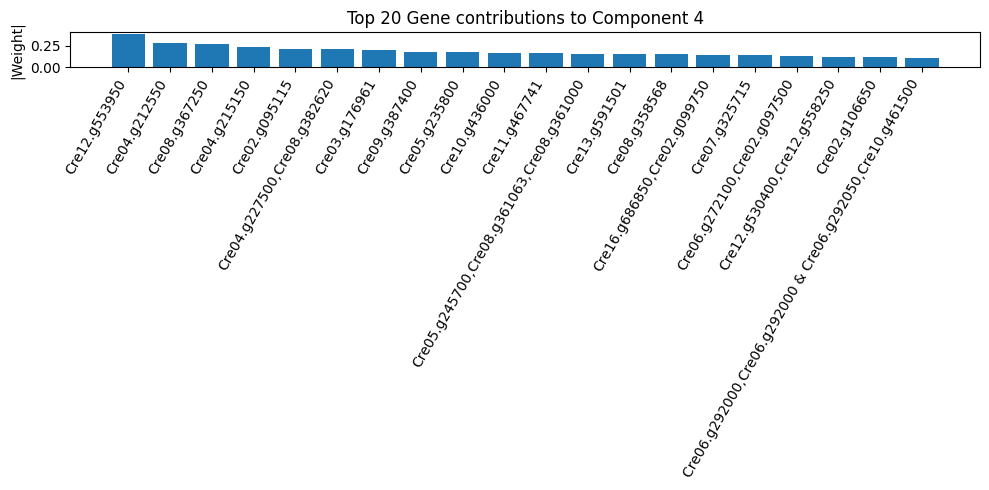

In [ ]:
k = 3  # component index (0 = Component 1)
N = 20 # how many top genes to show

weights = np.abs(U[:,k])
top_idx = np.argsort(weights)[::-1][:N]

plt.figure(figsize=(10,5))
plt.bar(np.array(X.columns)[top_idx], weights[top_idx])
plt.title(f"Top {N} Gene contributions to Component {k+1}")
plt.ylabel("|Weight|")
plt.xticks(rotation=60, ha='right')
plt.tight_layout()
plt.show()


## GO profiling

In [ ]:
# === Assume you already have X, Y, and ran cca_pmd ===
# U, V, D = cca_pmd(X_scaled, Y_scaled, penaltyx=0.3, penaltyz=0.3, K=4, standardize=False)

# Capture the gene list that matches U
genes_used = X.columns[:U.shape[0]]
print(f"U shape: {U.shape}, Genes used: {len(genes_used)}")

# g:Profiler client
gp = GProfiler(return_dataframe=True)

# Parameters
K = U.shape[1]        # number of canonical components
threshold = 0.1       # weight threshold for gene selection
background_genes = genes_used.tolist()  # background = all tested genes

for k in range(K):
    print(f"\n=== Component {k+1} ===")
    weights = U[:, k]
    
    # Select genes above threshold
    selected_genes = [genes_used[i] for i in range(len(weights)) if abs(weights[i]) > threshold]
    print(f"Selected {len(selected_genes)} genes for enrichment")
    
    # Skip if no genes pass threshold
    if len(selected_genes) == 0:
        print("⚠️ No genes passed threshold; skipping enrichment.")
        continue

    # Save gene list
    pd.Series(selected_genes).to_csv(f"cca_component{k+1}_genes.txt", index=False, header=False)

    # Run GO enrichment
    enrich_results = gp.profile(
        organism='creinhardtii',
        query=selected_genes,
        no_evidences=False,
        user_threshold=0.05,
        sources=['GO:BP', 'GO:MF', 'GO:CC'],
        background=background_genes
    )

    # Handle case where no enrichment found
    if enrich_results.empty:
        print("⚠️ No significant GO terms found.")
        continue

    # Save enrichment results
    enrich_results.to_csv(f"cca_component{k+1}_GO_enrichment.csv", index=False)

    # Plot top 15 terms
    sig = enrich_results[enrich_results['p_value'] < 0.05].head(15)
    if not sig.empty:
        plt.figure(figsize=(8,6))
        plt.barh(sig['name'], -np.log10(sig['p_value']))
        plt.xlabel('-log10(p-value)')
        plt.title(f'Top GO enrichment terms (Component {k+1})')
        plt.gca().invert_yaxis()
        plt.tight_layout()
        plt.show()
    else:
        print("⚠️ No GO terms below p<0.05 to plot.")


U shape: (564, 4), Genes used: 564

=== Component 1 ===
Selected 15 genes for enrichment
⚠️ No significant GO terms found.

=== Component 2 ===
Selected 23 genes for enrichment
⚠️ No significant GO terms found.

=== Component 3 ===
Selected 15 genes for enrichment
⚠️ No significant GO terms found.

=== Component 4 ===
Selected 17 genes for enrichment
⚠️ No significant GO terms found.


## Same trend graphs but with cca weights

In [ ]:
genes_to_flag = ['Cre01.g000650', 'Cre01.g012150', 'Cre01.g024800', 'Cre01.g025600', 'Cre01.g033450', 'Cre01.g034150', 'Cre01.g034250', 'Cre01.g036050', 'Cre01.g036100', 'Cre01.g040250', 'Cre01.g045500', 'Cre01.g055000', 'Cre02.g076200', 'Cre02.g077700', 'Cre02.g077750']
data = pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/cca_correlated_genes_lightregimes_with_weights.csv')
regime_to_freq = {
    '20h_HL': 10000,
    '2h-2h': 120,
    '10min-10min': 10,
    '5min-5min': 5,
    '1min-1min': 1,
    '30s-30s': 0.5
}
regime_order = list(regime_to_freq.keys())
data = data[data['light_regime'].isin(regime_order)].copy()
data['freq'] = data['light_regime'].map(regime_to_freq)
regime_df = pd.DataFrame({'light_regime': regime_order})
regime_df['freq'] = regime_df['light_regime'].map(regime_to_freq)
all_genes = genes_to_flag #sorted(data['gene'].unique()) if not data.empty else []
for gene in all_genes:
    gene_data = data[data['gene'] == gene][['light_regime', 'gene_weight']].copy()
    merged = regime_df.merge(gene_data, on='light_regime', how='left')
    merged['gene_weight'] = merged['gene_weight'].fillna(0)
    x = merged['freq'].values
    y = merged['gene_weight'].values
    plt.figure(figsize=(8, 5))
    plt.scatter(x, y, color='blue', alpha=0.7, label="Gene weight")
    plt.plot(x, y, color='orange', linestyle='-', label="Trend")
    plt.xscale('log')
    plt.xticks(ticks=[regime_to_freq[r] for r in regime_order],
        labels=regime_order,rotation=45)
    #plt.ylim(0,1)
    plt.xlabel("Light switching frequency (1/min)")
    plt.ylabel("Gene weight")
    plt.title(f"Gene weight across regimes – {gene}")
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()
    plt.tight_layout()
    plt.show()

### Other cca from  R code

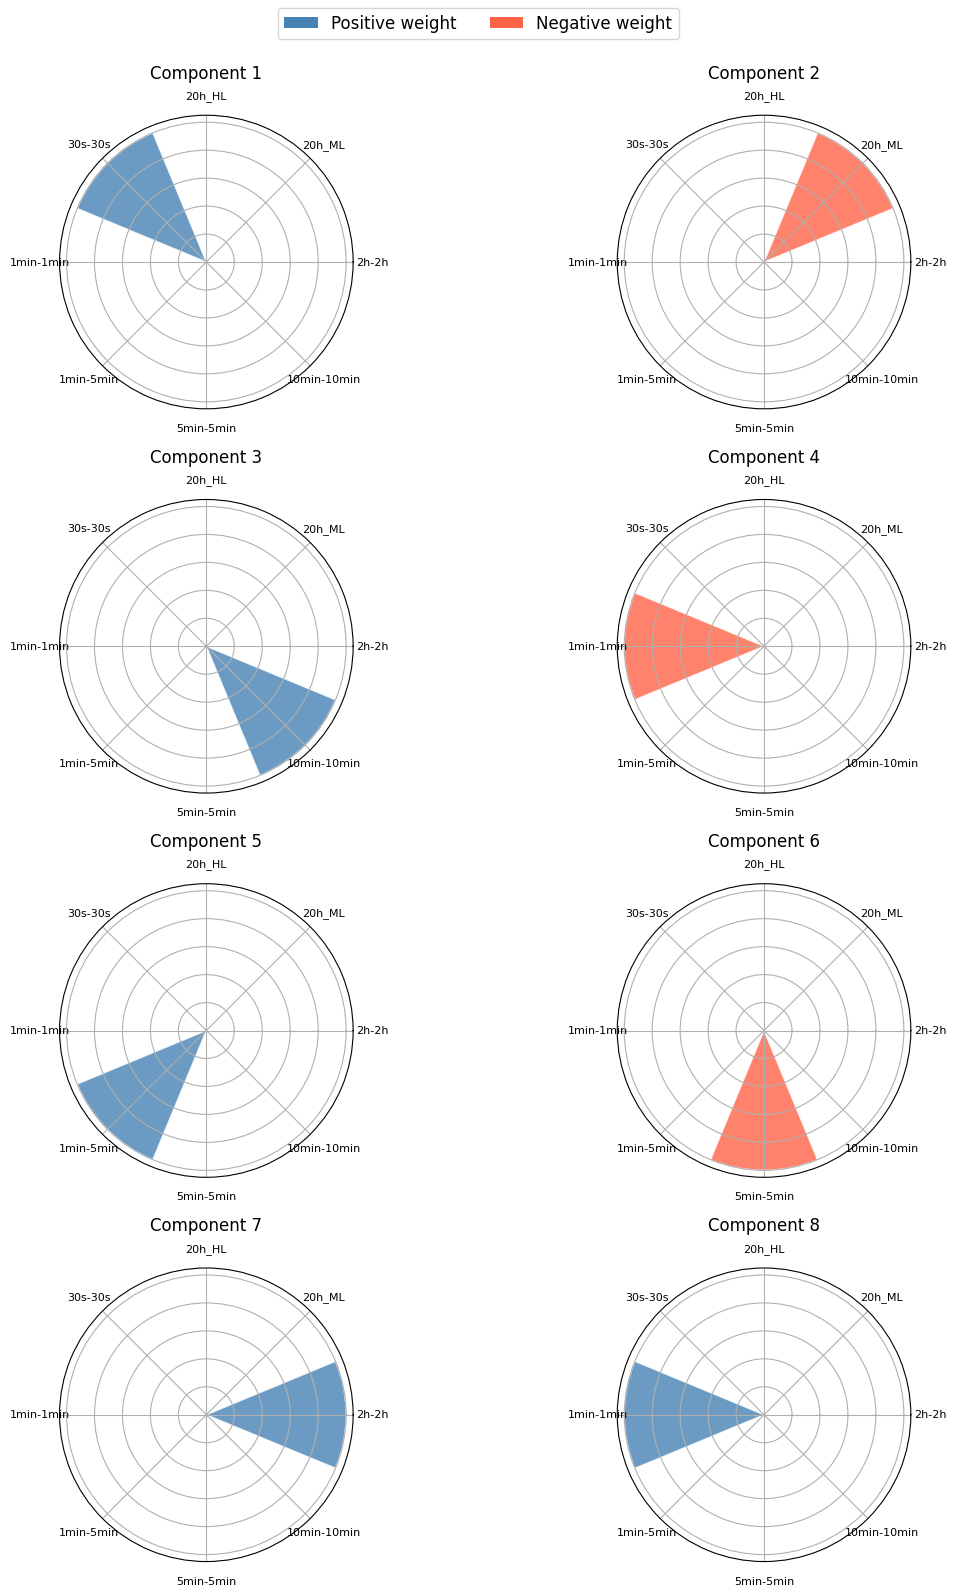

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch

# Load CSV
df = pd.read_csv("/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/sCCA/STANDARD_sCCA_full_results_orderedY.csv")
light_df = df[df['type'] == 'light_regime']

# Define the fixed order of light regimes
regime_order = [ "2h-2h", "20h_ML", "20h_HL", "30s-30s", "1min-1min", "1min-5min", "5min-5min", "10min-10min"]
n_regimes = len(regime_order)

components = sorted(light_df['component'].unique())

fig, axes = plt.subplots(4, 2, figsize=(12, 16), subplot_kw={'polar': True})
axes = axes.flatten()

for i, comp in enumerate(components[:8]):
    ax = axes[i]
    
    comp_data = light_df[light_df['component'] == comp].set_index('name')
    comp_data = comp_data.reindex(regime_order)  # force consistent order
    
    weights = comp_data['weight'].values
    labels = comp_data.index.values
    
    angles = np.linspace(0, 2*np.pi, n_regimes, endpoint=False)
    radii = np.abs(weights)
    colors = ['steelblue' if w > 0 else 'tomato' for w in weights]
    
    ax.bar(angles, radii, width=2*np.pi/n_regimes, color=colors,
           edgecolor='white', alpha=0.8)
    
    ax.set_xticks(angles)
    ax.set_xticklabels(labels, fontsize=8)
    ax.set_yticklabels([])
    ax.set_title(f"Component {comp}", va='bottom')

# Remove extra subplots if fewer than 8 components
for j in range(len(components), len(axes)):
    fig.delaxes(axes[j])

# Add legend
legend_elements = [Patch(facecolor='steelblue', label='Positive weight'),
                   Patch(facecolor='tomato', label='Negative weight')]
fig.legend(handles=legend_elements, loc='upper center', ncol=2, fontsize=12)

plt.tight_layout(rect=[0,0,1,0.97])
plt.show()


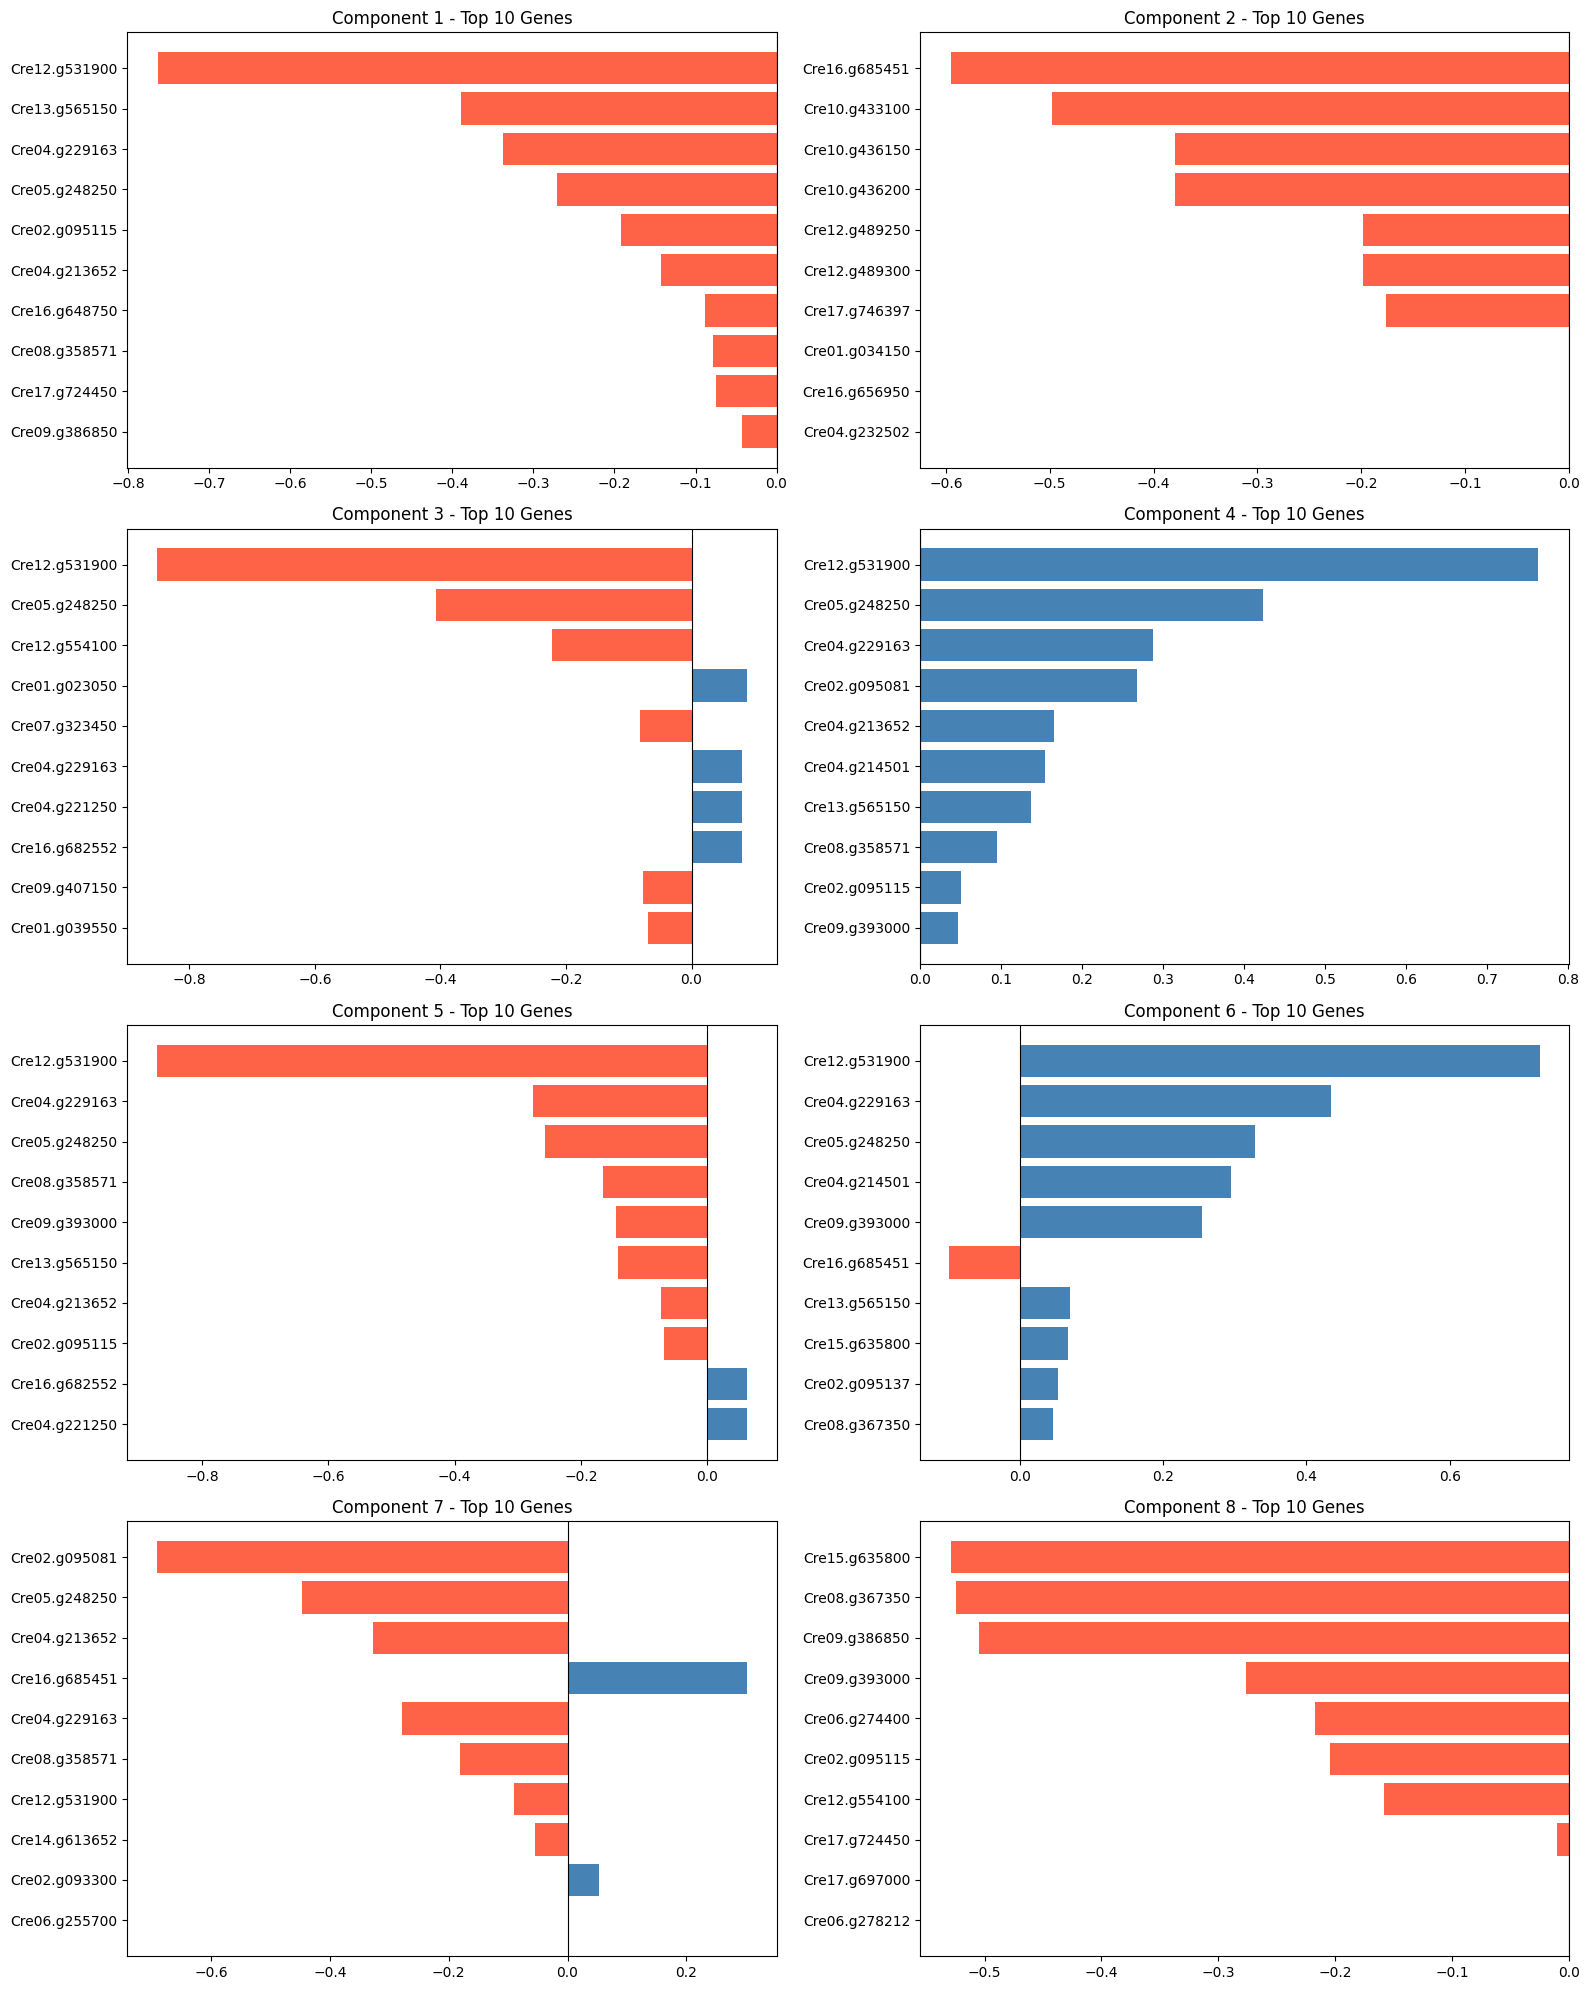

In [ ]:
# Load results
#df = pd.read_csv("/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/sCCA/STANDARD_sCCA_full_results.csv")

# Filter to genes only
gene_df = df[df['type'] == 'gene']

# Components to plot
components = sorted(gene_df['component'].unique())

# Set up grid (e.g. 4x2 for 8 components)
fig, axes = plt.subplots(4, 2, figsize=(16, 20))
axes = axes.flatten()

for i, comp in enumerate(components[:8]):
    ax = axes[i]
    
    comp_data = gene_df[gene_df['component'] == comp].copy()
    
    # Pick top 10 genes by absolute weight
    top_genes = comp_data.reindex(comp_data['weight'].abs().sort_values(ascending=False).index)[:10]
    
    # Plot bar chart (signed weights)
    ax.barh(top_genes['name'], top_genes['weight'], color=['steelblue' if w > 0 else 'tomato' for w in top_genes['weight']])
    
    ax.set_title(f"Component {comp} - Top 10 Genes")
    ax.axvline(0, color='black', linewidth=0.8)
    ax.invert_yaxis()  # largest bar on top

plt.tight_layout()
plt.show()


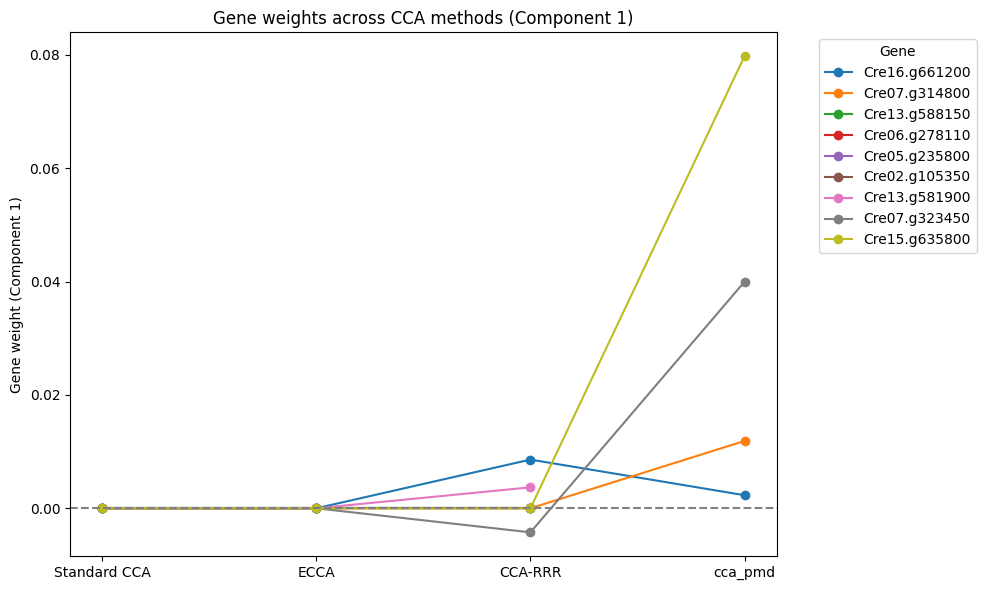

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# === Parameters ===
genes_of_interest = [
'Cre16.g661200',
'Cre07.g314800',
'Cre13.g588150',
'Cre06.g278110',
'Cre05.g235800',
'Cre02.g105350',
'Cre13.g581900',
'Cre07.g323450','Cre15.g635800']

files = {
    'Standard CCA': "/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/sCCA/STANDARD_sCCA_full_results.csv",
    'ECCA': "/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/sCCA/ECCA_results.csv",
    'CCA-RRR': "/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/sCCA/CCA_rr_component_results.csv",
    'cca_pmd': "/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/sCCA/python_scca_pmd_results.csv"
}

all_dfs = []

for method, path in files.items():
    df = pd.read_csv(path)
    df = df[
        (df['component'] == 1) & 
        (df['type'] == 'gene') & 
        (df['name'].isin(genes_of_interest))
    ]
    df['method'] = method
    all_dfs.append(df)

combined_df = pd.concat(all_dfs)

plt.figure(figsize=(10, 6))
for gene in genes_of_interest:
    subset = combined_df[combined_df['name'] == gene]
    plt.plot(subset['method'], subset['weight'], marker='o', label=gene)

plt.axhline(0, linestyle='--', color='gray')
plt.ylabel("Gene weight (Component 1)")
plt.title("Gene weights across CCA methods (Component 1)")
plt.legend(title="Gene", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


## PCA on Y to then apply cca with pmd

AKA   *PCA-based whitening:*



In [25]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LassoCV

# --- 0) Construire X (mutant x gènes) et Y (mutant x light_regime) ---
# df doit contenir: mutant_ID, mutated_genes, light_regime, y2_slope
#df= data#pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/Bayesian_latest_phase2(5.18).csv')
df = df[df['mutant_ID'].notna() & df['mutated_genes'].notna()]

df['presence'] = 1
X = df.pivot_table(index='mutant_ID', columns='mutated_genes',
                   values='presence', fill_value=0)

# Y = df.pivot_table(index='mutant_ID', columns='light_regime',
#                    values='y2_slope', aggfunc='mean')
Y = Y_rc
common = X.index.intersection(Y.index)
X = X.loc[common]
Y = Y.loc[common]
Y = Y.fillna(Y.mean())                       # imputation simple
X = X.loc[:, X.var() > 0]                    # drop colonnes constantes
# --- 1) PCA sur Σ_Y (équivalent à PCA sur Y standardisé) ---
yscaler = StandardScaler()
Y_scaled = yscaler.fit_transform(Y)
K = 6#min(Y_white.shape[1], 2 )               # ex: 6 premières PCs

pca = PCA(n_components=K)                 # garde toutes les composantes
Y_scores = pca.fit_transform(Y_scaled)       # = Y V (en base standardisée)

# (option) whitening pour variance=1 par PC
Y_white = Y_scores / pca.singular_values_
# Choisir combien de PCs on cible avec le Lasso

# --- 2) Lasso: prédire chaque PC de Y via X pour obtenir U parcimonieux ---
# Standardiser X (sans centrer si sparse/binaire)
xscaler = StandardScaler(with_mean=False)
X_scaled = xscaler.fit_transform(X)

alphas = None  # laisse LassoCV choisir
lasso_cv_kwargs = dict(cv=5, n_alphas=100, max_iter=5000, alphas=alphas)

U_coefs = []
for k in range(K):
    yk = Y_white[:, k]
    model = LassoCV(**lasso_cv_kwargs).fit(X_scaled, yk)
    U_coefs.append(model.coef_)

# Matrice U: gènes x PCs
U = pd.DataFrame(np.column_stack(U_coefs),
                 index=X.columns,
                 columns=[f"PC{k+1}" for k in range(K)])

# --- 3) Résultats utiles ---
# a) Scree plot: pca.explained_variance_ratio_ (si tu veux tracer)
explained = pd.Series(pca.explained_variance_ratio_,
                      index=[f"PC{i+1}" for i in range(Y_white.shape[1])])

# b) Top gènes par PC (par valeur absolue des coeffs)
def top_genes_for_pc(U, pc, n=15):
    return U[pc].abs().sort_values(ascending=False).head(n).to_frame("abs_coef").join(U[[pc]])

top_PC1 = top_genes_for_pc(U, "PC6", n=25)
print(top_PC1)
# idem pour PC2, PC3, ...

# --- 4) (option) Y_blanchi sous forme DataFrame avec labels PC ---
Y_whitened_df = pd.DataFrame(Y_white, index=Y.index,
                             columns=[f"PC{i+1}" for i in range(Y_white.shape[1])])

# Objets finaux:
# - explained : variance expliquée par PC (pour scree plot)
# - Y_whitened_df : scores blanchis par PC (échantillons x PCs)
# - U : coefficients Lasso (gènes x PCs) = association gènes↔directions phénotypiques
# - top_PC1 (etc.) : gènes majeurs pour chaque PC


# Sort genes by their strongest coefficient magnitude
gene_order = U.abs().max(axis=1).sort_values(ascending=False).index[:50]  # top 50 genes
plt.figure(figsize=(10, 8))
sns.heatmap(U.loc[gene_order], cmap='coolwarm', center=0, annot=False)
plt.title("Lasso coefficients: genes ↔ phenotype PCs")
plt.xlabel("Phenotype PCs")
plt.ylabel("Genes")
plt.tight_layout()
plt.show()

loadings = pd.DataFrame(pca.components_.T,
                        index=Y.columns,  # original light regimes
                        columns=[f"PC{i+1}" for i in range(pca.n_components_)])

plt.figure(figsize=(8, 6))
sns.heatmap(loadings, cmap='coolwarm', center=0, annot=True, fmt=".2f") #.iloc[:, :2]
plt.title("Light regime loadings on phenotype PCs")
plt.xlabel("PCs")
plt.ylabel("Light regimes")
plt.tight_layout()
plt.show()

KeyboardInterrupt: 

/home/imokhtatif/miniconda3/envs/myenv/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


Top 3 mutants on PC1:
 mutant_ID
LMJ.RY0402.242694(1)    4.758351
LMJ.RY0402.127455(1)    4.745955
LMJ.RY0402.236807(1)    4.676297
Name: PC1, dtype: float64
Bottom 3 mutants on PC1:
 mutant_ID
LMJ.RY0402.191784(1)   -7.558750
LMJ.RY0402.224491(1)   -6.760802
LMJ.RY0402.182572(1)   -5.885691
Name: PC1, dtype: float64
Top 3 mutants on PC2:
 mutant_ID
LMJ.RY0402.102320(1)    2.708442
LMJ.RY0402.065715(2)    2.683248
LMJ.RY0402.056638(1)    2.531589
Name: PC2, dtype: float64
Bottom 3 mutants on PC2:
 mutant_ID
LMJ.RY0402.052609(1)   -4.174905
LMJ.RY0402.092547(3)   -3.873084
LMJ.RY0402.189319(1)   -3.191568
Name: PC2, dtype: float64
Top 3 mutants on PC3:
 mutant_ID
LMJ.RY0402.209208(1)    2.891579
LMJ.RY0402.244771(1)    2.232073
LMJ.RY0402.172376(1)    2.211788
Name: PC3, dtype: float64
Bottom 3 mutants on PC3:
 mutant_ID
LMJ.RY0402.151654(1)   -2.688017
LMJ.RY0402.163237(1)   -2.592193
LMJ.RY0402.184967(2)   -2.450839
Name: PC3, dtype: float64
Top 3 mutants on PC4:
 mutant_ID
LMJ.RY0402

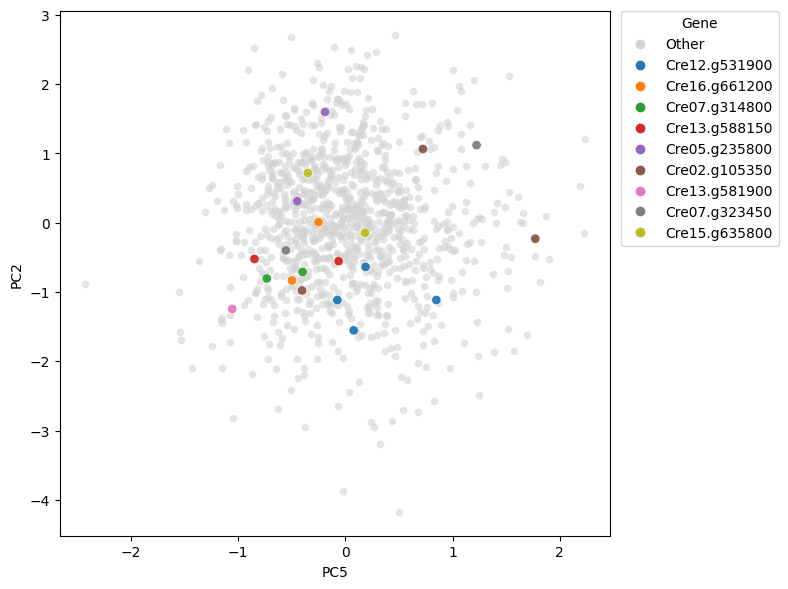

In [84]:
# Scores = YV
Y_scores = pd.DataFrame(
    pca.transform(Y_scaled),
    index=Y.index,
    columns=[f"PC{i+1}" for i in range(pca.n_components_)]
)

# Example: top 3 and bottom 3 mutants on PC1
for i in range(1,8):
    pc = f"PC{i}"
    top3 = Y_scores[pc].nlargest(3)
    bottom3 = Y_scores[pc].nsmallest(3)
    print(f"Top 3 mutants on PC{i}:\n", top3)
    print(f"Bottom 3 mutants on PC{i}:\n", bottom3)

# Scatter plot PC1 vs PC2
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import seaborn as sns
import matplotlib.pyplot as plt

# 1) gènes d'intérêt présents dans X
interesting_genes = [
    "Cre12.g531900","Cre16.g661200","Cre07.g314800","Cre13.g588150",
    "Cre06.g278110","Cre05.g235800","Cre02.g105350","Cre13.g581900",
    "Cre07.g323450","Cre15.g635800"
]
present_cols = [g for g in interesting_genes if g in X.columns]

# 2) pour chaque mutant: choisir le gène (si plusieurs -> on prend le premier dans present_cols)
def pick_gene(row):
    hits = [g for g in present_cols if row[g] > 0]
    return hits[0] if len(hits) >= 1 else "Other"

label_per_mutant = X[present_cols].apply(pick_gene, axis=1)

# 3) palette couleur: une par gène + gris pour "Other"
palette_colors = sns.color_palette(n_colors=max(1, len(present_cols)))
palette = {g: c for g, c in zip(present_cols, palette_colors)}
palette["Other"] = "lightgray"

# 4) ordre de légende (uniquement catégories présentes)
hue_order = [g for g in present_cols if g in set(label_per_mutant)] + ["Other"]

# 5) scatter PC3 vs PC2
# split
df_plot = Y_scores.copy()
df_plot["gene_label"] = label_per_mutant.reindex(df_plot.index)

others = df_plot[df_plot["gene_label"] == "Other"]
interest = df_plot[df_plot["gene_label"] != "Other"]

hue_order_int = [g for g in present_cols if g in interest["gene_label"].unique()]

plt.figure(figsize=(8,6))
ax = sns.scatterplot(  # fond en dessous
    data=others, x="PC5", y="PC2",
    color="lightgray", s=30, alpha=0.6, linewidth=0, zorder=1, label="Other"
)
sns.scatterplot(        # points colorés au-dessus
    data=interest, x="PC5", y="PC2",
    hue="gene_label", hue_order=hue_order_int, palette=palette,
    s=45, alpha=0.95, linewidth=0.4, edgecolor="white", zorder=2, legend=False
)

# légende propre (une entrée par gène + Other)
from matplotlib.lines import Line2D
handles = [Line2D([0],[0], marker='o', linestyle='', color='lightgray', label='Other')]
handles += [Line2D([0],[0], marker='o', linestyle='', color=palette[g], label=g) for g in hue_order_int]
ax.legend(handles=handles, title="Gene", bbox_to_anchor=(1.02,1), loc="upper left", borderaxespad=0)

plt.tight_layout(); plt.show()


In [90]:
data5 = data[data['light_regime']=='5min-5min']
interesting_genes = [
    "Cre12.g531900","Cre16.g661200","Cre07.g314800","Cre13.g588150",
    "Cre06.g278110","Cre05.g235800","Cre02.g105350","Cre13.g581900",
    "Cre07.g323450","Cre15.g635800"
]
vals = set(data['mutated_genes'].dropna().astype(str).unique())

for el in interesting_genes:
    print(el in vals)

True
True
True
True
False
True
True
True
True
True


/tmp/ipykernel_206266/2876548873.py:34: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(False))


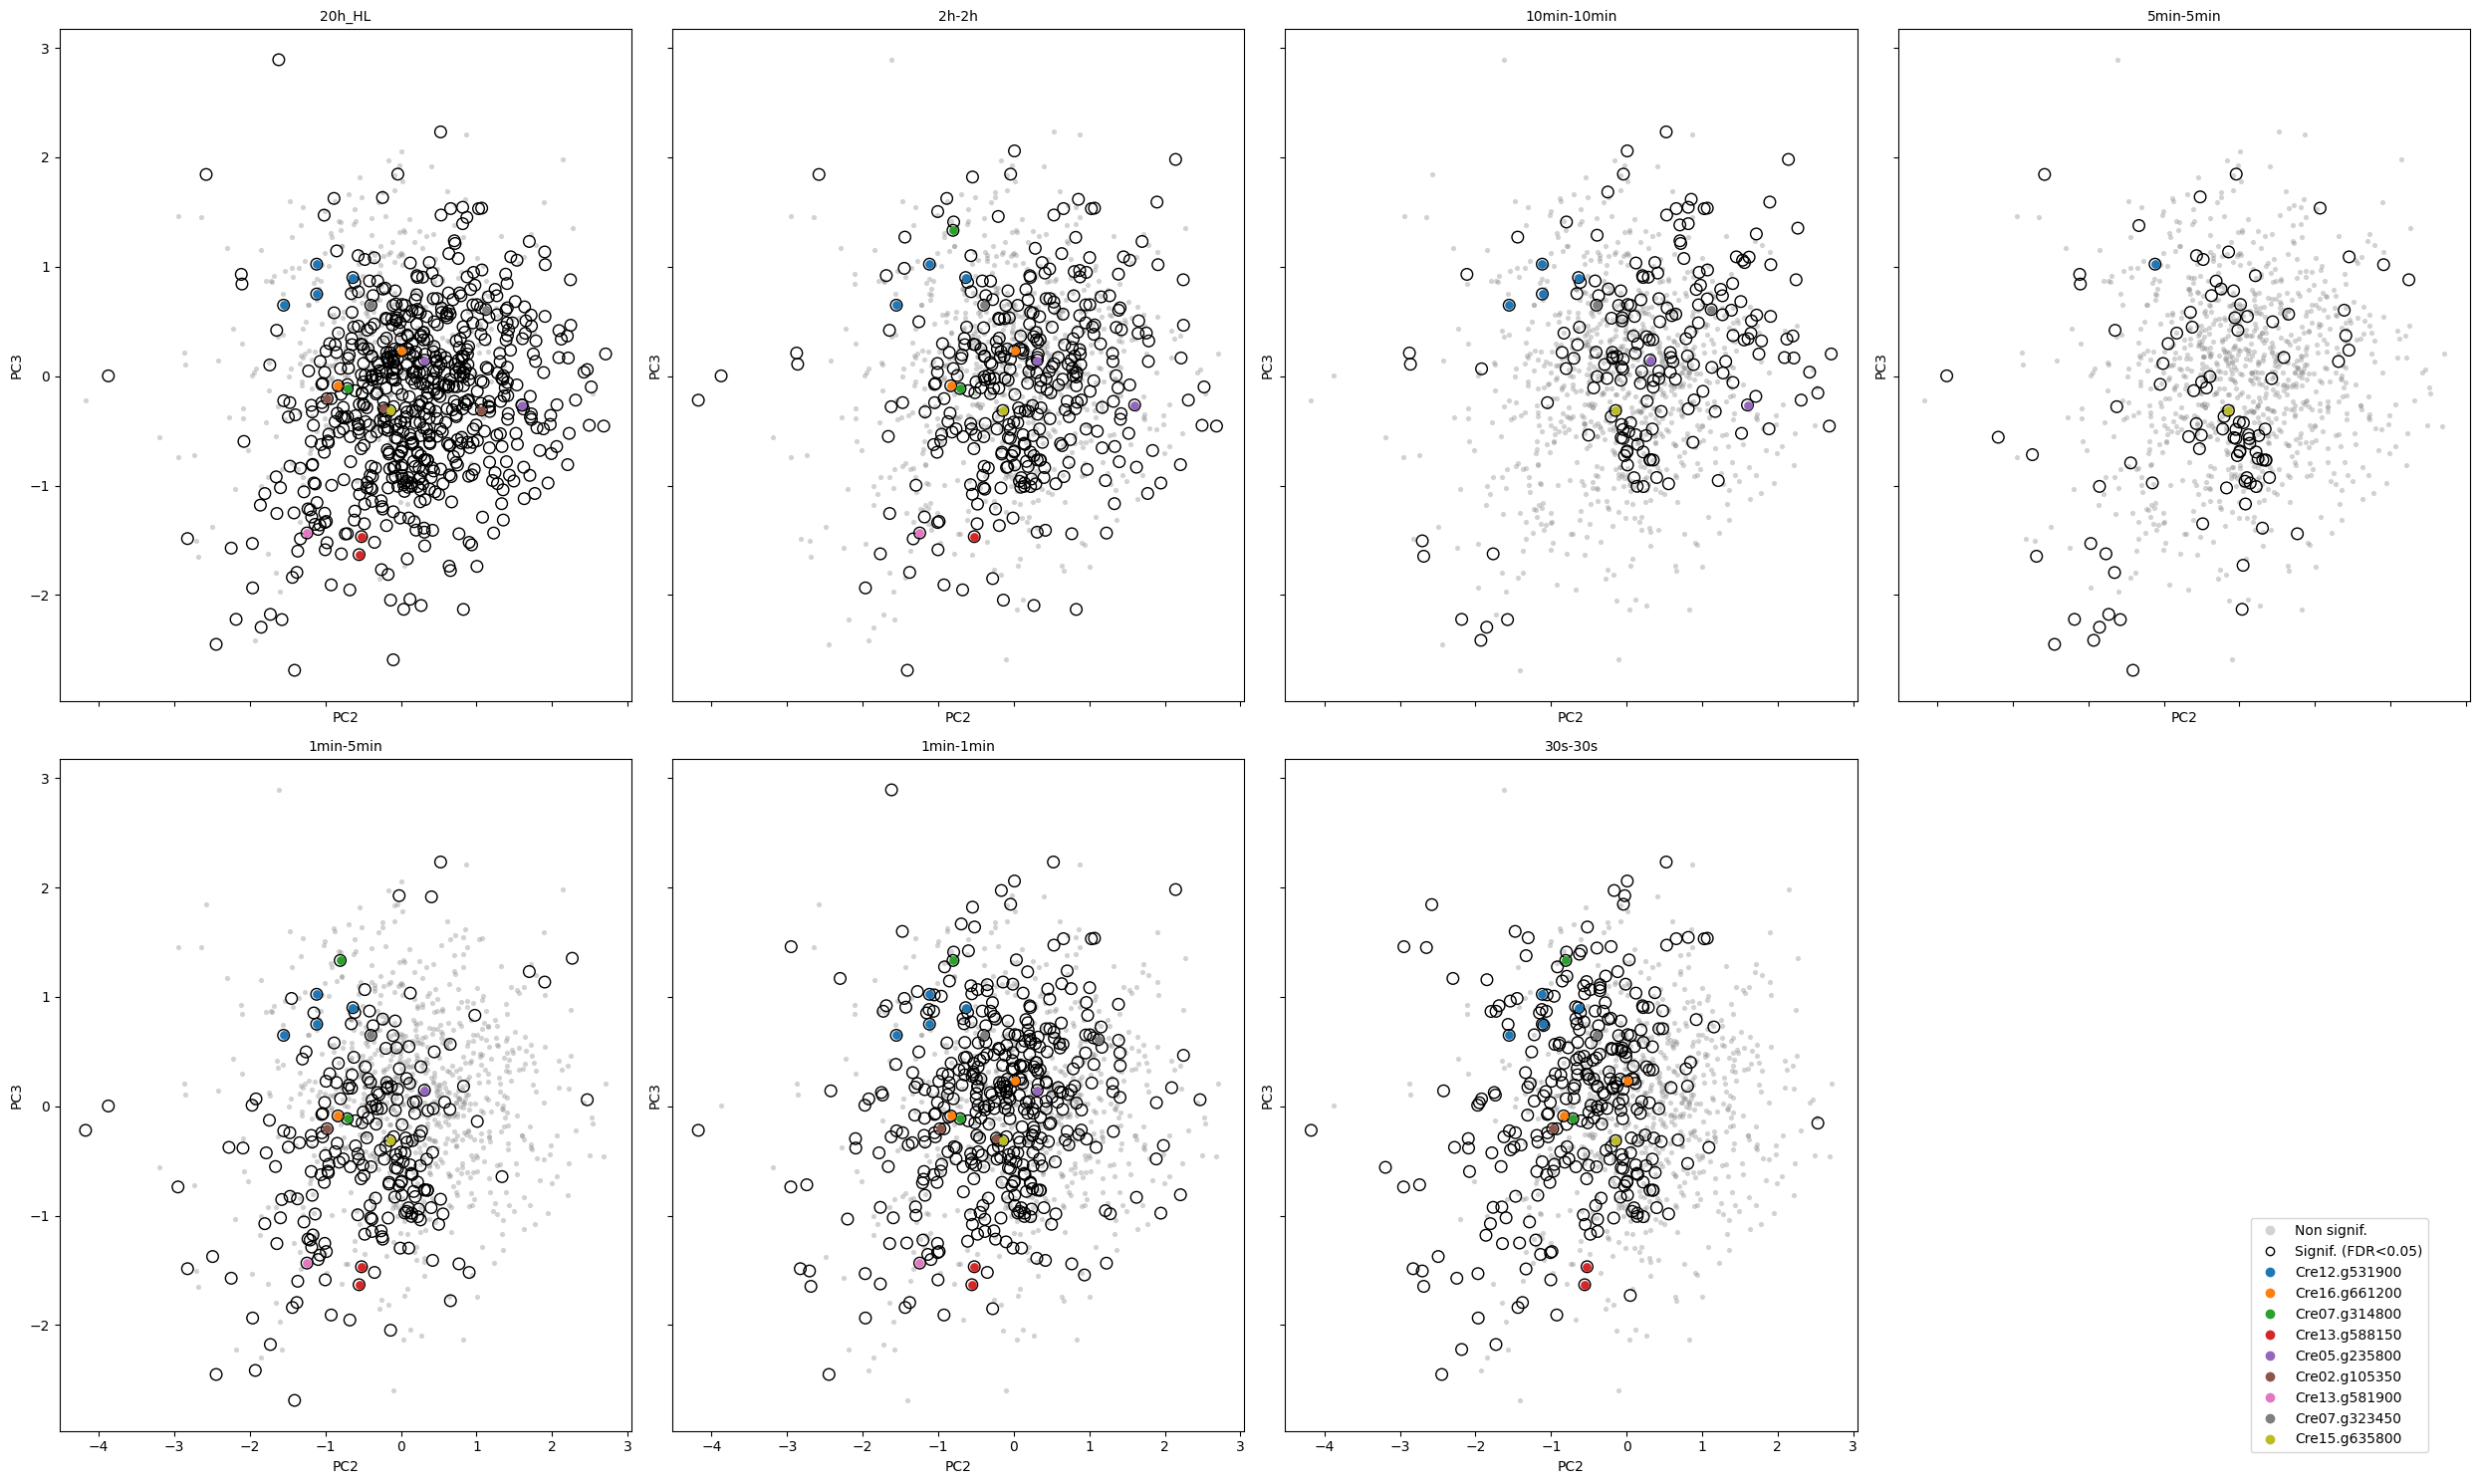

In [91]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

alpha = 0.05
regime_order = ['20h_HL','2h-2h','10min-10min','5min-5min', '1min-5min','1min-1min','30s-30s']
regime_order = [r for r in regime_order if r in df_stats['light_regime'].unique()]

interesting_genes = [
    "Cre12.g531900","Cre16.g661200","Cre07.g314800","Cre13.g588150",
    "Cre06.g278110","Cre05.g235800","Cre02.g105350","Cre13.g581900",
    "Cre07.g323450","Cre15.g635800"
]

# --- présence gènes d’intérêt par mutant ---
present_cols = [g for g in interesting_genes if g in X.columns]
G = X.reindex(Y_scores.index).reindex(columns=present_cols, fill_value=0).astype(bool)

# affecte un seul gène (le premier match) sinon 'None'
gene_label = pd.Series('None', index=Y_scores.index)
for g in present_cols:
    gene_label.loc[(gene_label == 'None') & G[g]] = g

# palette pour gènes d’intérêt
palette_genes = {g: c for g, c in zip(present_cols, sns.color_palette(n_colors=len(present_cols)))}

# --- significativité par régime (wide bool) ---
sig_wide = (df_stats[['mutant_ID','light_regime','p_adj']]
            .dropna()
            .assign(sig=lambda d: d['p_adj'] < alpha)
            .pivot_table(index='mutant_ID', columns='light_regime', values='sig', aggfunc='max')
            .reindex(Y_scores.index)
            .fillna(False))

# --- figure 8x8 ---
nrows, ncols = 2, 4
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(25, 15), sharex=True, sharey=True)
axes = axes.ravel()

for i, reg in enumerate(regime_order):
    ax = axes[i]
    sig = sig_wide[reg]
    ns  = ~sig

    # 1) non-significatifs (gris, fond)
    ax.scatter(Y_scores.loc[ns,'PC2'], Y_scores.loc[ns,'PC3'],
               s=14, alpha=0.35, color='gray', linewidths=0, zorder=1)

    # 2) cercles noirs (sous la couleur)
    ax.scatter(Y_scores.loc[sig,'PC2'], Y_scores.loc[sig,'PC3'],
               s=70, facecolors='none', edgecolors='black',
               linewidths=1.0, zorder=2)

    # 3) gènes d’intérêt colorés (tout en haut)
    for g in present_cols:
        m = sig & gene_label.eq(g)
        if m.any():
            ax.scatter(Y_scores.loc[m,'PC2'], Y_scores.loc[m,'PC3'],
                       s=40, alpha=1.0, color=palette_genes[g],
                       linewidths=0, zorder=5)

    # 3) cercle noir pour tous les significatifs
    ax.scatter(Y_scores.loc[sig, 'PC2'], Y_scores.loc[sig, 'PC3'],
               s=70, facecolors='none', edgecolors='black', linewidths=0.1, zorder=4)

    ax.set_title(reg, fontsize=10)
    ax.set_xlabel('PC2'); ax.set_ylabel('PC3')

# axes vides masqués
for j in range(len(regime_order), nrows*ncols):
    axes[j].axis('off')

# légende (une fois)
from matplotlib.lines import Line2D
handles = [
    Line2D([0],[0], marker='o', linestyle='', color='lightgray', label='Non signif.'),
    Line2D([0],[0], marker='o', linestyle='', color='black', markerfacecolor='none', label='Signif. (FDR<0.05)'),
]
handles += [Line2D([0],[0], marker='o', linestyle='', color=palette_genes[g], label=g) for g in present_cols]
fig.legend(handles=handles, title='', loc='lower right', bbox_to_anchor=(0.98, 0.02))

plt.tight_layout()
plt.show()


(1000, 2)


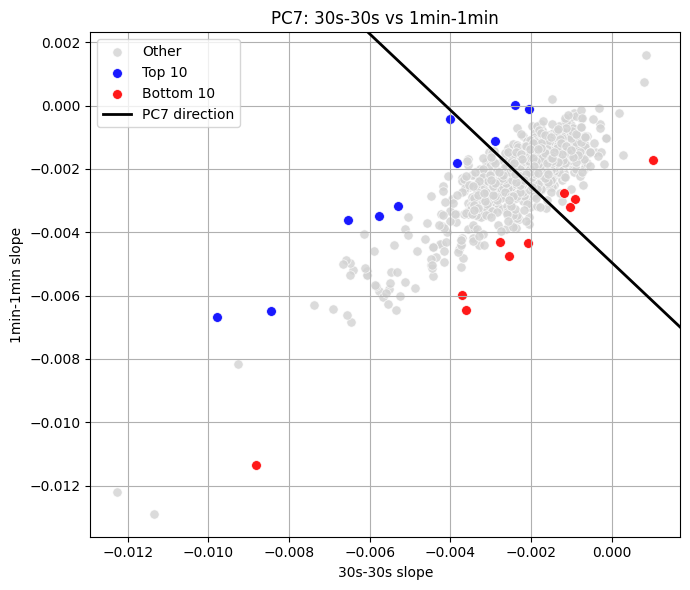

Non-NaN rows: 1083 / 1083


In [20]:
import numpy as np, pandas as pd, seaborn as sns, matplotlib.pyplot as plt

PC_TARGET = "PC7"          # e.g. "PC4"
N_PER_SIDE = 10
x_col, y_col = "30s-30s", "1min-1min"

# --- extremes on target PC ---
pc_num = int(PC_TARGET.replace("PC",""))
top_ids = Y_scores[PC_TARGET].nlargest(N_PER_SIDE).index
bot_ids = Y_scores[PC_TARGET].nsmallest(N_PER_SIDE).index

# --- data for the two regimes ---
plot_df = Y[[x_col, y_col]].dropna().copy()
plot_df['group'] = 'Other'
plot_df.loc[plot_df.index.isin(top_ids), 'group'] = f'Top {N_PER_SIDE}'
plot_df.loc[plot_df.index.isin(bot_ids), 'group'] = f'Bottom {N_PER_SIDE}'

# --- PC direction in ORIGINAL units ---
ix, iy = Y.columns.get_loc(x_col), Y.columns.get_loc(y_col)
v_std = pca.components_[pc_num - 1][[ix, iy]]
sx, sy = yscaler.scale_[ix], yscaler.scale_[iy]
v_orig = np.array([v_std[0] / sx, v_std[1] / sy])
v_orig = v_orig / np.linalg.norm(v_orig)
center = plot_df[[x_col, y_col]].mean().values

# choose line extent from data limits
xmin, xmax = plot_df[x_col].min(), plot_df[x_col].max()
ymin, ymax = plot_df[y_col].min(), plot_df[y_col].max()
L = 1.2 * np.hypot(xmax - xmin, ymax - ymin)
t = np.linspace(-L, L, 200)
pc_line = center[None, :] + t[:, None] * v_orig

# --- plot ---
plt.figure(figsize=(7,6))

# scatter plot first: Other -> Top -> Bottom, so top/bottom points overlay
sns.scatterplot(
    data=plot_df[plot_df['group'] == 'Other'], x=x_col, y=y_col,
    color='lightgrey', alpha=0.8, s=45, label='Other'
)
sns.scatterplot(
    data=plot_df[plot_df['group'] == f'Top {N_PER_SIDE}'], x=x_col, y=y_col,
    color='blue', alpha=0.9, s=50, label=f'Top {N_PER_SIDE}'
)
sns.scatterplot(
    data=plot_df[plot_df['group'] == f'Bottom {N_PER_SIDE}'], x=x_col, y=y_col,
    color='red', alpha=0.9, s=50, label=f'Bottom {N_PER_SIDE}'
)

# axis limits from scatter
xmin, xmax = plt.xlim()
ymin, ymax = plt.ylim()

# center & length to match scatter bounds
center = plot_df[[x_col, y_col]].mean().values
max_extent = max(xmax - xmin, ymax - ymin) / 2
t = np.linspace(-max_extent, max_extent, 1000)
pc_line = center[None, :] + t[:, None] * v_orig

# add PC direction line
plt.plot(pc_line[:,0], pc_line[:,1], color='black', lw=2, label=f'{PC_TARGET} direction')
print(pc_line.shape)
# restore original limits
plt.xlim(xmin, xmax)
plt.ylim(ymin, ymax)

plt.title(f'{PC_TARGET}: {x_col} vs {y_col}')
plt.xlabel(f'{x_col} slope'); plt.ylabel(f'{y_col} slope')
plt.legend(title='', loc='best')
plt.grid(True)
plt.tight_layout()
plt.show()
# Count non-NaN rows for the two columns together
non_na_count = Y[[x_col, y_col]].dropna().shape[0]
total_count = Y.shape[0]

print(f"Non-NaN rows: {non_na_count} / {total_count}")


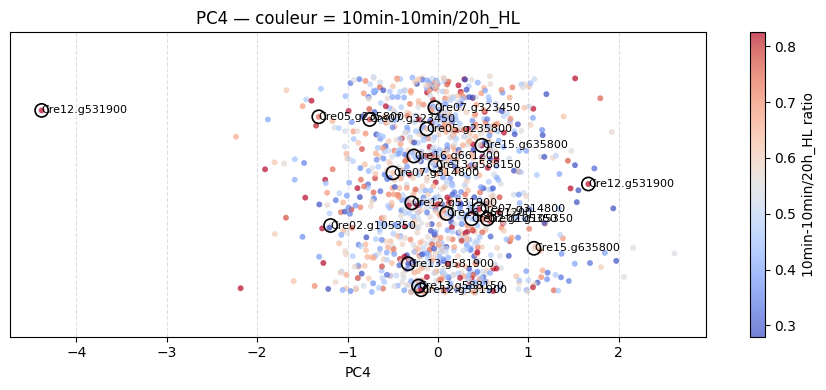

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --------- paramètres ----------
PC_TARGET = "PC4"
slope1, slope2 = "10min-10min", "20h_HL"

# Liste des gènes à mettre en évidence
genes_to_show = [
    "Cre12.g531900","Cre16.g661200","Cre07.g314800","Cre13.g588150",
    "Cre06.g278110","Cre05.g235800","Cre02.g105350","Cre13.g581900",
    "Cre07.g323450","Cre15.g635800"
]

# --------- YV (scores) et ratio ----------
Y_scores = pd.DataFrame(
    pca.transform(Y_scaled),
    index=Y.index,
    columns=[f"PC{i+1}" for i in range(pca.n_components_)]
)
ratio = (Y[slope1] / Y[slope2]).replace([np.inf, -np.inf], np.nan)

plot_df = (
    Y_scores[[PC_TARGET]]
    .assign(ratio=ratio)
    .dropna(subset=["ratio"])
)

# --------- quelles lignes portent ces gènes ? ----------
# On part de X (mutant × gènes, 1/0). Si besoin, intersecte avec cols existantes.
present_cols = [g for g in genes_to_show if g in X.columns]
labels = X[present_cols].apply(
    lambda row: ", ".join([g for g, v in row.items() if v > 0]),
    axis=1
) if present_cols else pd.Series("", index=X.index)

# Restreindre aux points présents dans plot_df
labels = labels.reindex(plot_df.index).fillna("")
has_gene = labels != ""

# --------- affichage : jitter + clipping couleur ----------
vmin, vmax = np.percentile(plot_df["ratio"], [5, 95])
j = 0.06
y = np.random.uniform(-j, j, size=len(plot_df))  # jitter vertical stable pour ce run

plt.figure(figsize=(9, 4))
sc = plt.scatter(
    plot_df[PC_TARGET], y,
    c=plot_df["ratio"], cmap="coolwarm",
    vmin=vmin, vmax=vmax,
    s=18, alpha=0.7, edgecolors="none"
)

# surcouche: mutants porteurs des gènes d’intérêt (cercle + label)
plt.scatter(
    plot_df.loc[has_gene, PC_TARGET],
    y[has_gene.values],
    facecolors="none", edgecolors="black", s=90, linewidths=1.2, label="gènes d'intérêt"
)

for mid, gene_text in labels[has_gene].items():
    plt.text(
        plot_df.at[mid, PC_TARGET],
        y[plot_df.index.get_loc(mid)],
        gene_text, fontsize=8, ha="left", va="center"
    )

plt.xlabel(PC_TARGET); plt.yticks([]); plt.ylim(-j*1.4, j*1.4)
plt.title(f"{PC_TARGET} - {slope1}/{slope2}")
cb = plt.colorbar(sc); cb.set_label(f"{slope1}/{slope2} ratio")
plt.grid(axis="x", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()


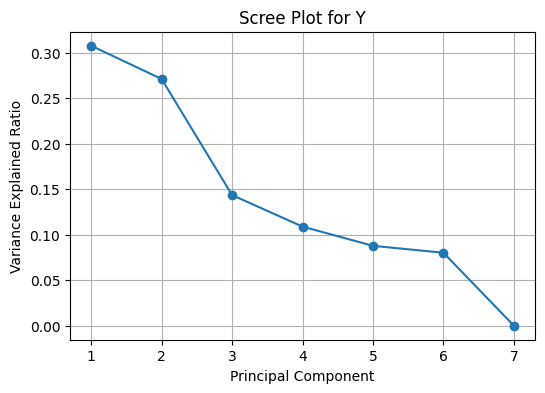

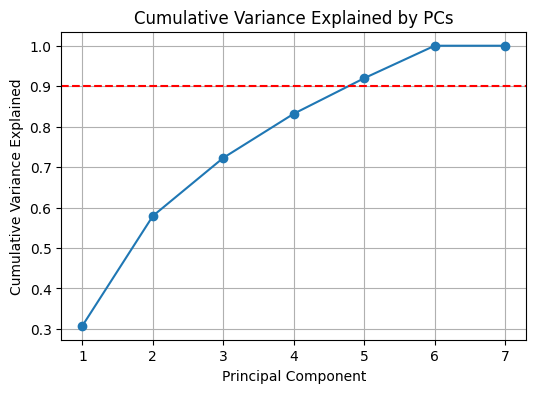

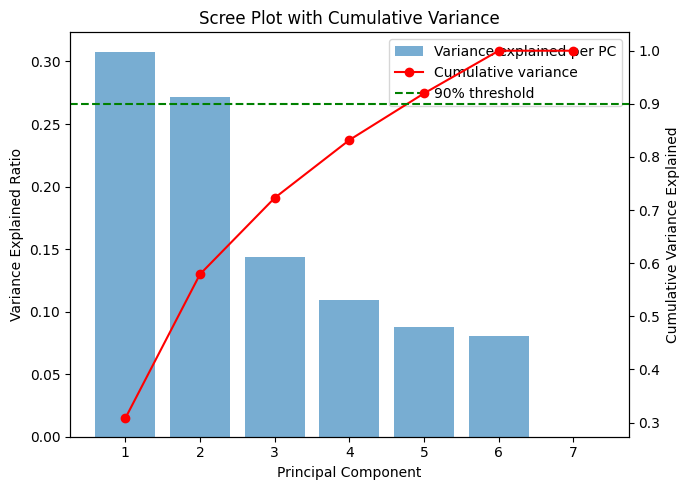

In [ ]:
# Standardize Y (important for PCA)
yscaler = StandardScaler()
Y_scaled = yscaler.fit_transform(Y)

# PCA
pca = PCA()
pca.fit(Y_scaled)

# Scree plot
plt.figure(figsize=(6,4))
plt.plot(range(1, len(pca.explained_variance_ratio_)+1),
         pca.explained_variance_ratio_, marker='o')
plt.xlabel('Principal Component')
plt.ylabel('Variance Explained Ratio')
plt.title('Scree Plot for Y')
plt.grid(True)
plt.show()

# Optional: cumulative variance
plt.figure(figsize=(6,4))
plt.plot(range(1, len(pca.explained_variance_ratio_)+1),
         pca.explained_variance_ratio_.cumsum(), marker='o')
plt.xlabel('Principal Component')
plt.ylabel('Cumulative Variance Explained')
plt.title('Cumulative Variance Explained by PCs')
plt.axhline(y=0.9, color='r', linestyle='--')  # 90% variance line
plt.grid(True)
plt.show()

import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# --- Standardize Y ---
yscaler = StandardScaler()
Y_scaled = yscaler.fit_transform(Y)

# --- PCA ---
pca = PCA()
pca.fit(Y_scaled)

# --- Explained variance ---
var_ratio = pca.explained_variance_ratio_
cum_var = np.cumsum(var_ratio)
pcs = np.arange(1, len(var_ratio) + 1)

# --- Plot ---
fig, ax1 = plt.subplots(figsize=(7,5))

# Bars: variance ratio per PC
ax1.bar(pcs, var_ratio, alpha=0.6, label='Variance explained per PC')
ax1.set_xlabel('Principal Component')
ax1.set_ylabel('Variance Explained Ratio')
ax1.set_xticks(pcs)

# Line: cumulative variance
ax2 = ax1.twinx()
ax2.plot(pcs, cum_var, color='red', marker='o', label='Cumulative variance')
ax2.set_ylabel('Cumulative Variance Explained')

# Optional: horizontal line for threshold (e.g., 90%)
ax2.axhline(y=0.9, color='green', linestyle='--', label='90% threshold')

# Legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='best')

plt.title('Scree Plot with Cumulative Variance')
plt.tight_layout()
plt.show()


# Varimax rotation

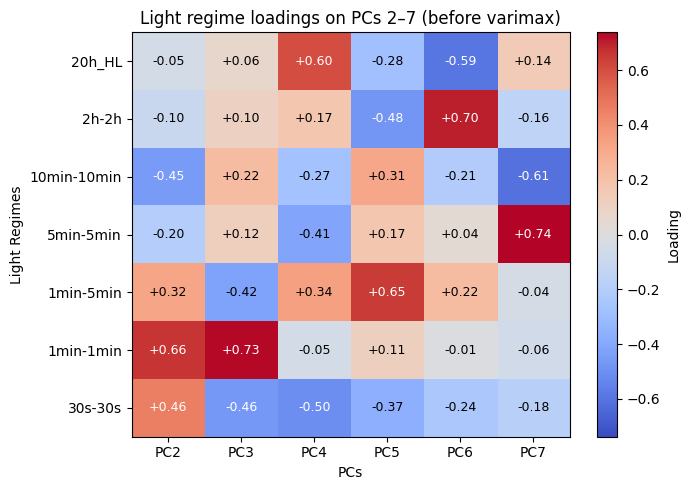

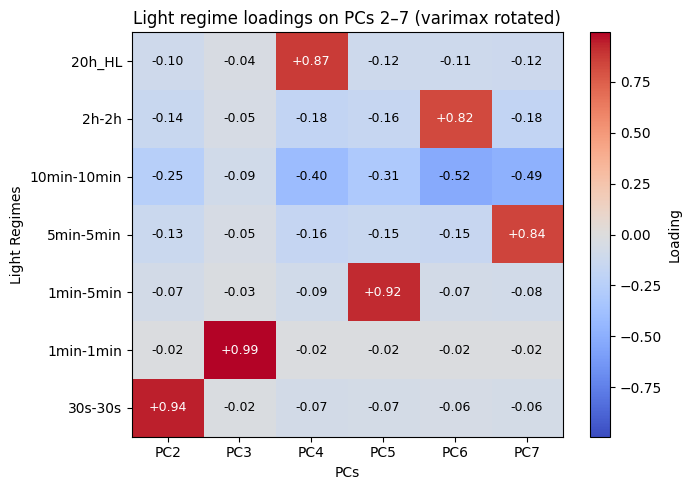

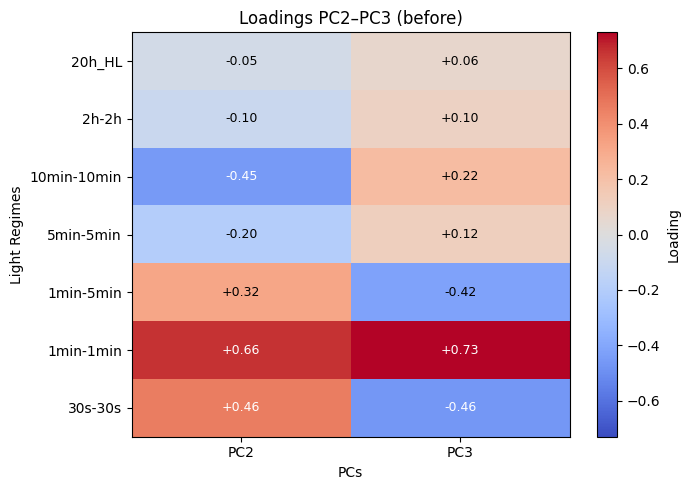

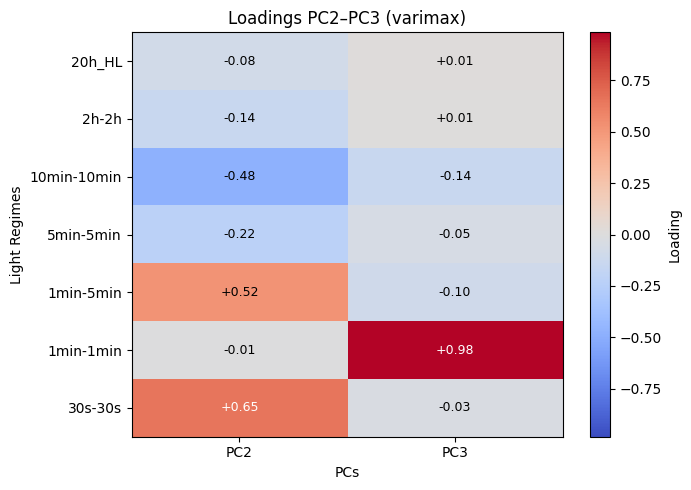

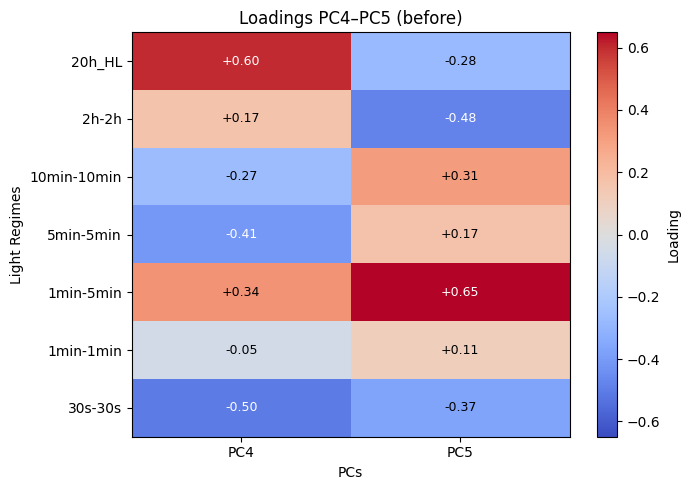

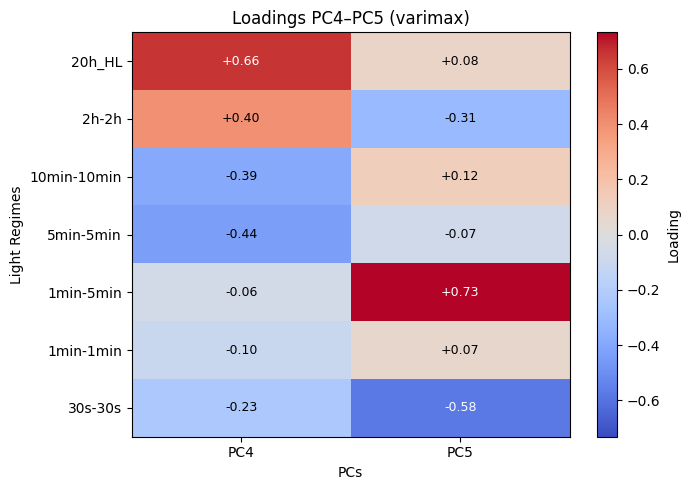

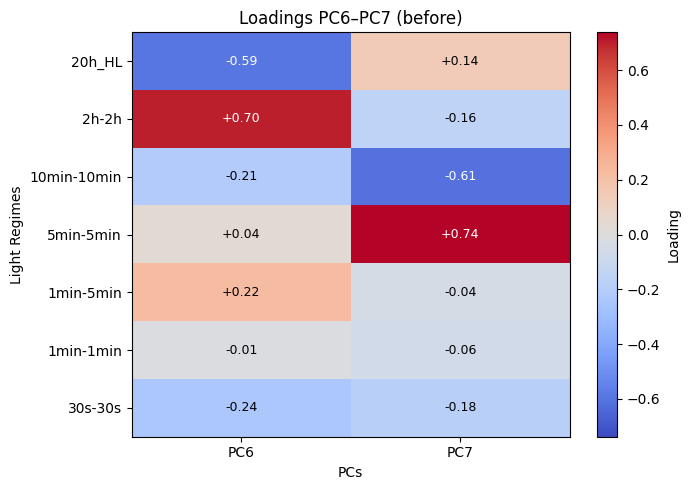

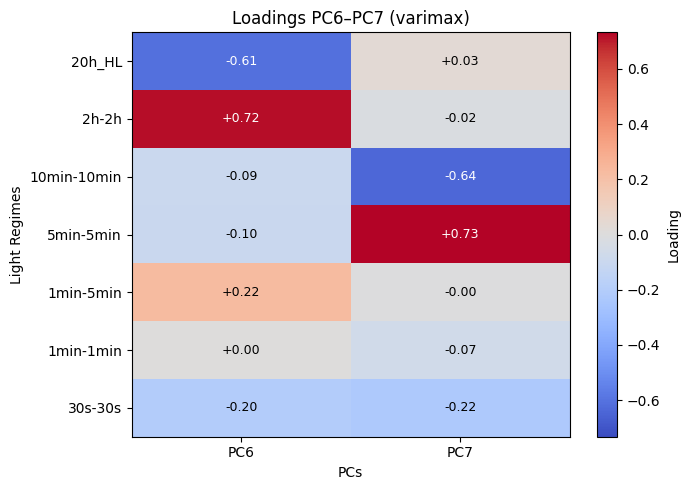

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# --- Varimax (orthogonal) ---
def varimax(Phi, gamma=1.0, q=100, tol=1e-6):
    p, k = Phi.shape
    R = np.eye(k)
    d_old = 0
    for _ in range(q):
        Lambda = Phi @ R
        # Kaiser normalization inside objective
        M = Phi.T @ (Lambda**3 - (gamma/p) * Lambda @ np.diag(np.diag(Lambda.T @ Lambda)))
        U, S, Vt = np.linalg.svd(M, full_matrices=False)
        R = U @ Vt
        d = S.sum()
        if d_old and (d - d_old) < tol:
            break
        d_old = d
    return Phi @ R, R

# --- Heatmap helper (no custom colors; labels like your figure) ---
def plot_loadings_heatmap(loadings, regime_names, pc_names, title):
    L = np.asarray(loadings, dtype=float)
    vmax = np.nanmax(np.abs(L)) or 1.0  # échelle symétrique
    fig, ax = plt.subplots(figsize=(7, 5))
    im = ax.imshow(L, aspect='auto', cmap='coolwarm', vmin=-vmax, vmax=vmax)

    # ticks + labels
    ax.set_yticks(range(len(regime_names)))
    ax.set_yticklabels(regime_names)
    ax.set_xticks(range(len(pc_names)))
    ax.set_xticklabels(pc_names)
    ax.set_xlabel('PCs')
    ax.set_ylabel('Light Regimes')
    ax.set_title(title)

    # annotations chiffrées au centre des cellules
    # couleur du texte inversée si |val| est élevée pour la lisibilité
    for i in range(L.shape[0]):
        for j in range(L.shape[1]):
            val = L[i, j]
            txt_color = 'white' if abs(val) > 0.6 * vmax else 'black'
            ax.text(j, i, f"{val:+.2f}", ha='center', va='center', fontsize=9, color=txt_color)

    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label('Loading')
    plt.tight_layout()
    plt.show()

# =============================
# Y: DataFrame (rows=mutants, cols=light_regimes), values = mean y2_slope
# =============================

# 1) Standardize columns (PCA sur corrélation)
Y_std = pd.DataFrame(
    StandardScaler(with_mean=True, with_std=True).fit_transform(Y.values),
    index=Y.index, columns=Y.columns
)

# 2) PCA avec au moins 7 composantes
pca = PCA(n_components=7, svd_solver='full', random_state=0)
scores = pca.fit_transform(Y_std.values)          # (n_mutants × 7)
loadings_all = pca.components_.T                  # (n_regimes × 7), colonnes = PC1..PC7
regimes = list(Y.columns)
# Desired order
regime_order = ['20h_HL','2h-2h','10min-10min','5min-5min','1min-5min','1min-1min','30s-30s']

# After PCA:
loadings_all = pca.components_.T                  # (n_regimes × 7)
regimes_orig = list(Y.columns)

# Keep only regimes that exist, in desired order
regimes = [r for r in regime_order if r in regimes_orig]
order_idx = [regimes_orig.index(r) for r in regimes]

# Reorder BOTH the matrix and the labels
loadings_all = loadings_all[order_idx, :]

# ---- PC2–PC7 block
idx = np.arange(1, 7)
L_2_7 = loadings_all[:, idx]
S_2_7 = scores[:, idx]

# Varimax
L_2_7_rot, R_2_7 = varimax(L_2_7.copy())
S_2_7_rot = S_2_7 @ R_2_7

pc_names_2_7 = [f"PC{i}" for i in range(2, 8)]

# ✅ Use the ORDERED labels
plot_loadings_heatmap(
    loadings=L_2_7,
    regime_names=regimes,
    pc_names=pc_names_2_7,
    title="Light regime loadings on PCs 2–7 (before varimax)"
)
plot_loadings_heatmap(
    loadings=L_2_7_rot,
    regime_names=regimes,
    pc_names=pc_names_2_7,
    title="Light regime loadings on PCs 2–7 (varimax rotated)"
)

# Pairwise rotations (use reordered matrix & labels)
def rotate_pair(j, k):
    ii = np.array([j-1, k-1])
    L = loadings_all[:, ii]
    L_rot, _ = varimax(L.copy())
    plot_loadings_heatmap(L, regimes, [f"PC{j}", f"PC{k}"], f"Loadings PC{j}–PC{k} (before)")
    plot_loadings_heatmap(L_rot, regimes, [f"PC{j}", f"PC{k}"], f"Loadings PC{j}–PC{k} (varimax)")

rotate_pair(2, 3); rotate_pair(4, 5); rotate_pair(6, 7)

# --- Optionnel: reconstruire une matrice de loadings 1..7 où 2..7 sont tournés ---
# L_full_rot = loadings_all.copy()
# L_full_rot[:, idx] = L_2_7_rot
# (PC1 reste inchangé)


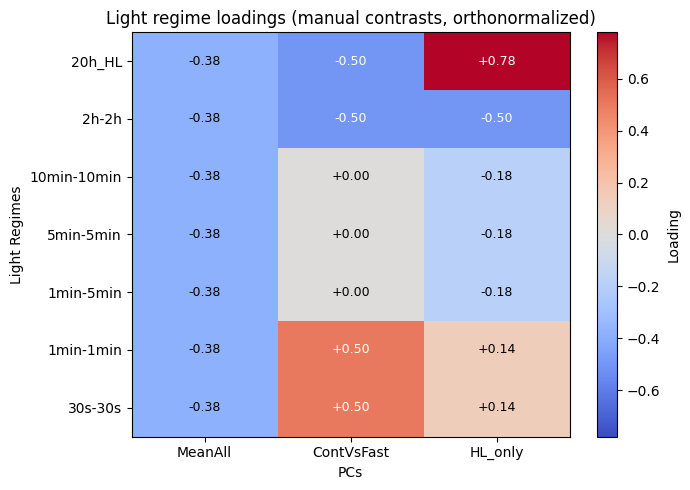


=== MeanAll: top + (sensibles au motif) ===
mutant_ID
LMJ.RY0402.073018(2)(1)    7.803
LMJ.RY0402.086572(1)(1)    7.629
LMJ.RY0402.205790(1)(1)    7.540
LMJ.RY0402.135873(1)(1)    7.490
LMJ.RY0402.234238(2)(1)    7.442
LMJ.RY0402.087011(1)(1)    6.951
LMJ.RY0402.222419(1)(1)    6.762
LMJ.RY0402.198898(1)(1)    5.902
LMJ.RY0402.242694(1)(1)    4.689
LMJ.RY0402.127455(1)(1)    4.676
Name: MeanAll, dtype: float64

=== MeanAll: top - (anti-motif) ===
mutant_ID
LMJ.RY0402.247339(1)(1)   -3.919
LMJ.RY0402.145536(3)(1)   -3.968
LMJ.RY0402.254326(1)(1)   -4.036
LMJ.RY0402.104493(1)(1)   -4.248
LMJ.RY0402.064241(1)(1)   -4.725
LMJ.RY0402.245390(1)(1)   -4.952
LMJ.RY0402.172780(2)(1)   -4.999
LMJ.RY0402.182572(1)(1)   -5.955
LMJ.RY0402.224491(1)(1)   -6.830
LMJ.RY0402.191784(1)(1)   -7.628
Name: MeanAll, dtype: float64

=== ContVsFast: top + (sensibles au motif) ===
mutant_ID
LMJ.RY0402.045285(1)(1)    2.212
LMJ.RY0402.065715(2)(1)    2.033
LMJ.RY0402.185266(3)(1)    2.016
LMJ.RY0402.123904(1)(

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# ---------- Heatmap (format demandé) ----------
def plot_loadings_heatmap(loadings, regime_names, pc_names, title):
    L = np.asarray(loadings, dtype=float)
    vmax = np.nanmax(np.abs(L)) or 1.0
    fig, ax = plt.subplots(figsize=(7, 5))
    im = ax.imshow(L, aspect='auto', cmap='coolwarm',
                   vmin=-vmax, vmax=vmax, interpolation='none')
    ax.set_yticks(range(len(regime_names))); ax.set_yticklabels(regime_names)
    ax.set_xticks(range(len(pc_names)));     ax.set_xticklabels(pc_names)
    ax.set_xlabel('PCs'); ax.set_ylabel('Light Regimes'); ax.set_title(title)
    for i in range(L.shape[0]):
        for j in range(L.shape[1]):
            val = L[i, j]
            ax.text(j, i, f"{val:+.2f}", ha='center', va='center',
                    fontsize=9, color=('white' if abs(val) > 0.6*vmax else 'black'))
    cbar = plt.colorbar(im, ax=ax); cbar.set_label('Loading')
    plt.tight_layout(); plt.show()

# ---------- 1) Ordonner Y ----------
regime_order = ['20h_HL','2h-2h','10min-10min','5min-5min','1min-5min','1min-1min','30s-30s']
Y = Y.loc[:, [r for r in regime_order if r in Y.columns]].copy()
regimes = list(Y.columns)
p = len(regimes)

# ---------- 2) Standardiser colonnes ----------
Y_std = pd.DataFrame(
    StandardScaler(with_mean=True, with_std=True).fit_transform(Y.values),
    index=Y.index, columns=regimes
)

# ---------- 3) Définir des contrastes (loadings forcés) ----------
# Exemple : V1 = moyenne ; V2 = continu vs rapide ; V3 = 20h_HL-only
contrasts = {
    "MeanAll": {r: 1 for r in regimes},                                  # tous +1
    "ContVsFast": {'20h_HL':+1, '2h-2h':+1, '1min-1min':-1, '30s-30s':-1},# le reste 0
    "HL_only": {'20h_HL': 1}                                             # le reste 0
}
# -> tu peux ajouter d’autres entrées {nom: {regime: poids, ...}}

# ---------- 4) Construire matrice V (p × k), normaliser colonnes ----------
V_cols, names = [], []
for name, wmap in contrasts.items():
    v = np.array([wmap.get(r, 0.0) for r in regimes], dtype=float)
    if np.allclose(v, 0):
        continue
    v = v / np.linalg.norm(v)
    V_cols.append(v); names.append(name)

V_stack = np.column_stack(V_cols)  # (p × k)

# ---------- 5) Orthonormaliser (QR) ----------
Q, R = np.linalg.qr(V_stack)       # colonnes orthonormées
V = Q                               # (p × k)
pc_names = names                    # garder les noms fournis

# ---------- 6) Scores mutants et “variance captée” ----------
S = Y_std.values @ V                # (n_mutants × k)
scores_df = pd.DataFrame(S, index=Y_std.index, columns=pc_names)

Sigma = np.cov(Y_std.values, rowvar=False)         # cov des régimes standardisés
var_along = pd.Series(np.diag(V.T @ Sigma @ V), index=pc_names)

# ---------- 7) Heatmap des loadings (tes contrastes) ----------
plot_loadings_heatmap(V, regimes, pc_names, "Light regime loadings (manual contrasts, orthonormalized)")

# ---------- 8) Tables triées des mutants par contraste ----------
# top positifs (plus sensibles au motif), et top négatifs (inverse)
def top_mutants(scores_df, comp, n=10):
    s = scores_df[comp].sort_values(ascending=False)
    return s.head(n), s.tail(n)

for comp in pc_names:
    top_pos, top_neg = top_mutants(scores_df, comp, n=10)
    print(f"\n=== {comp}: top + (sensibles au motif) ===")
    print(top_pos.round(3))
    print(f"\n=== {comp}: top - (anti-motif) ===")
    print(top_neg.round(3))

print("\nVariance le long de chaque contraste (sur Y standardisé) :")
print(var_along.round(3))
